# EDA Dataset Film TMDB dengan PySpark

Notebook ini digunakan untuk melakukan *Exploratory Data Analysis* terhadap dataset film hasil scraping dan enrichment dari TMDB.

Fokus analisis:
- Memahami ukuran, struktur, dan kualitas dataset.
- Mengecek duplikasi, missing value, format tanggal, dan nilai tidak wajar.
- Menganalisis distribusi rating, popularitas, vote, runtime, budget, revenue, genre, bahasa, aktor, sutradara, keyword, dan negara produksi.
- Menyiapkan insight awal untuk tahap preprocessing dan model rekomendasi film.

Notebook ini dibuat untuk dijalankan di **VSCode** menggunakan kernel Python dari `.venv` dan memproses data memakai **PySpark**.

## 1. Import Library

Cell ini mengimpor library utama yang dipakai selama EDA.

Library yang digunakan:
- `pyspark` untuk pemrosesan data skala besar.
- `pandas` untuk menampilkan hasil agregasi kecil.
- `matplotlib` untuk visualisasi.
- `pathlib` untuk manajemen path folder project.

In [1]:
from pathlib import Path
import os
import math
import json
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    IntegerType,
    LongType,
    DoubleType,
    BooleanType,
    StringType,
    DateType,
    TimestampType,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

## 2. Membuat SparkSession

Cell ini membuat `SparkSession`, yaitu pintu utama untuk memakai PySpark.

Konfigurasi yang dipakai:
- `local[*]` berarti Spark memakai semua core CPU lokal.
- `spark.driver.memory` dinaikkan agar lebih aman ketika membaca dataset puluhan ribu baris.
- `spark.sql.shuffle.partitions` dibuat tidak terlalu besar karena dataset masih dijalankan lokal.
- Arrow diaktifkan agar konversi hasil agregasi kecil dari Spark ke pandas lebih efisien.

In [2]:
spark = (
    SparkSession.builder
    .appName("TMDB Movie EDA - PySpark")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print("Spark master :", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)

Spark version: 4.1.2
Spark master : local[*]
Default parallelism: 12


## 3. Konfigurasi Path Dataset

Cell ini mencari file dataset secara otomatis dari beberapa kemungkinan lokasi.

Notebook ini mendukung beberapa nama file:
- `data/raw/tmdb/tmdb_movies_final_enriched.csv`
- `data/raw/tmdb/tmdb_movies_final_vote10_enriched.csv`
- `data/raw/tmdb/tmdb_movies_final_vote10.csv`
- `tmdb_movies_final_enriched.csv`

Kalau file kamu berbeda, cukup ubah variabel `DATA_PATH` secara manual.

In [3]:
PROJECT_ROOT = Path.cwd()

# Jika notebook dijalankan dari folder notebooks/, naik satu level ke root project
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "tmdb" / "tmdb_movies_final_enriched.csv",
    PROJECT_ROOT / "data" / "raw" / "tmdb" / "tmdb_movies_final_vote10_enriched.csv",
    PROJECT_ROOT / "data" / "raw" / "tmdb" / "tmdb_movies_final_vote10.csv",
    PROJECT_ROOT / "tmdb_movies_final_enriched.csv",
]

DATA_PATH = None
for candidate in DATA_CANDIDATES:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pindahkan CSV ke data/raw/tmdb/ atau ubah DATA_PATH secara manual."
    )

OUTPUT_DIR = PROJECT_ROOT / "data" / "interim" / "eda"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH   :", DATA_PATH)
print("OUTPUT_DIR  :", OUTPUT_DIR)
print("FIGURE_DIR  :", FIGURE_DIR)

PROJECT_ROOT: d:\Semester 6\BigData\movie-recommendation-bigdata
DATA_PATH   : d:\Semester 6\BigData\movie-recommendation-bigdata\data\raw\tmdb\tmdb_movies_final_enriched.csv
OUTPUT_DIR  : d:\Semester 6\BigData\movie-recommendation-bigdata\data\interim\eda
FIGURE_DIR  : d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures


## 4. Membaca Dataset CSV dengan PySpark

Cell ini membaca dataset menggunakan `spark.read.csv`.

Parameter penting:
- `header=True` karena file memiliki nama kolom.
- `inferSchema=True` agar Spark menebak tipe data awal.
- `multiLine=True` untuk berjaga-jaga jika ada teks panjang yang mengandung baris baru.
- `escape='"'` untuk menangani teks yang mengandung tanda kutip.

Setelah dibaca, data langsung di-cache karena akan dipakai berulang kali pada proses EDA.

In [4]:
df_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(str(DATA_PATH))
)

df_raw = df_raw.cache()

print("Jumlah baris:", df_raw.count())
print("Jumlah kolom:", len(df_raw.columns))
df_raw.printSchema()

Jumlah baris: 80713
Jumlah kolom: 36
root
 |-- id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- original_title: string (nullable = true)
 |-- original_language: string (nullable = true)
 |-- overview: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- genre_ids: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- popularity: double (nullable = true)
 |-- vote_average: double (nullable = true)
 |-- vote_count: integer (nullable = true)
 |-- adult: boolean (nullable = true)
 |-- video: boolean (nullable = true)
 |-- poster_path: string (nullable = true)
 |-- backdrop_path: string (nullable = true)
 |-- source_config: string (nullable = true)
 |-- source_start_date: date (nullable = true)
 |-- source_end_date: date (nullable = true)
 |-- source_page: integer (nullable = true)
 |-- collected_at: timestamp (nullable = true)
 |-- runtime: double (nullable = true)
 |-- status: string (nullable = true)
 |-- tagline: string (nullable =

## 5. Melihat Contoh Data Awal

Cell ini menampilkan beberapa baris pertama untuk memahami bentuk data asli.

Tujuannya:
- Memastikan dataset terbaca dengan benar.
- Melihat contoh format kolom list seperti `genres`, `top_cast`, `keywords`, dan `production_companies`.
- Mengecek apakah hasil enrichment sudah masuk.

In [5]:
df_raw.show(5, truncate=80)

+------+------------------------+---------------------------+-----------------+--------------------------------------------------------------------------------+------------+------------+----------------------------+----------+------------+----------+-----+-----+--------------------------------+--------------------------------+-------------+-----------------+---------------+-----------+--------------------------+-------+--------+--------------------------------------------------------------------------------+------+---------+---------+--------+------------------------------+------------------------------------------------------------+------------------------+--------------------------+---------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+-------------------+
|    id|             

## 6. Ringkasan Kolom dan Tipe Data

Cell ini membuat tabel ringkas berisi nama kolom dan tipe data yang terbaca oleh Spark.

Ini penting untuk menentukan kolom mana yang perlu:
- Diubah tipe datanya.
- Dipakai sebagai fitur numerik.
- Dipakai sebagai fitur kategorikal.
- Dipakai sebagai fitur teks untuk rekomendasi.

In [6]:
schema_pd = pd.DataFrame(
    [(field.name, field.dataType.simpleString()) for field in df_raw.schema.fields],
    columns=["column", "spark_dtype"]
)

schema_pd

,column,spark_dtype
0,id,int
1,title,string
2,original_title,string
3,original_language,string
4,overview,string
5,release_date,date
6,genre_ids,string
7,genres,string
8,popularity,double
9,vote_average,double


## 7. Data Dictionary Awal

Cell ini membuat data dictionary sederhana berdasarkan kolom dataset TMDB kamu.

Data dictionary ini bisa dipakai nanti untuk laporan atau dokumentasi project.

In [7]:
data_dictionary = {
    "id": "ID unik film dari TMDB.",
    "title": "Judul film.",
    "original_title": "Judul asli film.",
    "original_language": "Bahasa asli film.",
    "overview": "Sinopsis atau deskripsi singkat film.",
    "release_date": "Tanggal rilis film.",
    "genre_ids": "ID genre dari TMDB dalam format teks.",
    "genres": "Nama genre dari hasil mapping awal.",
    "popularity": "Skor popularitas dari TMDB.",
    "vote_average": "Rata-rata rating film dari pengguna TMDB.",
    "vote_count": "Jumlah vote/rating yang diterima film.",
    "adult": "Penanda apakah film termasuk konten dewasa.",
    "video": "Penanda apakah item merupakan video.",
    "poster_path": "Path poster film.",
    "backdrop_path": "Path backdrop film.",
    "source_config": "Konfigurasi scraping, misalnya vote10.",
    "source_start_date": "Tanggal awal window scraping.",
    "source_end_date": "Tanggal akhir window scraping.",
    "source_page": "Halaman TMDB discover saat data diambil.",
    "collected_at": "Waktu pengambilan data base movie.",
    "runtime": "Durasi film dalam menit.",
    "status": "Status rilis film.",
    "tagline": "Tagline film.",
    "budget": "Anggaran produksi film.",
    "revenue": "Pendapatan film.",
    "imdb_id": "ID film di IMDb.",
    "homepage": "Website resmi film.",
    "genres_detail": "Genre hasil enrichment detail.",
    "production_companies": "Perusahaan produksi.",
    "production_countries": "Negara produksi.",
    "spoken_languages": "Bahasa yang digunakan dalam film.",
    "director": "Sutradara film.",
    "writers": "Penulis film.",
    "top_cast": "Aktor utama film.",
    "keywords": "Keyword atau tag film dari TMDB.",
    "enriched_at": "Waktu proses enrichment dilakukan.",
}

dict_rows = [(col, data_dictionary.get(col, "-")) for col in df_raw.columns]
data_dictionary_pd = pd.DataFrame(dict_rows, columns=["column", "description"])

data_dictionary_pd

,column,description
0,id,ID unik film dari TMDB.
1,title,Judul film.
2,original_title,Judul asli film.
3,original_language,Bahasa asli film.
4,overview,Sinopsis atau deskripsi singkat film.
5,release_date,Tanggal rilis film.
6,genre_ids,ID genre dari TMDB dalam format teks.
7,genres,Nama genre dari hasil mapping awal.
8,popularity,Skor popularitas dari TMDB.
9,vote_average,Rata-rata rating film dari pengguna TMDB.


## 8. Standarisasi Tipe Data dan Feature Engineering Awal

Cell ini membuat dataframe `df` yang sudah lebih siap dianalisis.

Transformasi yang dilakukan:
- Mengubah `release_date` menjadi tipe tanggal.
- Membuat fitur `release_year`, `release_month`, dan `release_decade`.
- Membuat fitur finansial seperti `profit` dan `roi`.
- Membuat penanda apakah budget/revenue tersedia.
- Menghitung panjang teks untuk `overview` dan `tagline`.
- Menghitung jumlah item pada kolom list berbasis separator `|`.

Catatan: pada TMDB, nilai `budget = 0` atau `revenue = 0` sering berarti data tidak tersedia, bukan benar-benar nol.

In [8]:
df = df_raw

# Casting kolom dasar
df = (
    df
    .withColumn("id", F.col("id").cast(LongType()))
    .withColumn("popularity", F.col("popularity").cast(DoubleType()))
    .withColumn("vote_average", F.col("vote_average").cast(DoubleType()))
    .withColumn("vote_count", F.col("vote_count").cast(LongType()))
    .withColumn("runtime", F.col("runtime").cast(DoubleType()))
    .withColumn("budget", F.col("budget").cast(DoubleType()))
    .withColumn("revenue", F.col("revenue").cast(DoubleType()))
    .withColumn("release_date_parsed", F.to_date("release_date"))
    .withColumn("source_start_date_parsed", F.to_date("source_start_date"))
    .withColumn("source_end_date_parsed", F.to_date("source_end_date"))
)

# Fitur waktu
df = (
    df
    .withColumn("release_year", F.year("release_date_parsed"))
    .withColumn("release_month", F.month("release_date_parsed"))
    .withColumn("release_decade", (F.floor(F.col("release_year") / 10) * 10).cast(IntegerType()))
)

# Fitur finansial
df = (
    df
    .withColumn("has_budget", F.when(F.col("budget") > 0, 1).otherwise(0))
    .withColumn("has_revenue", F.when(F.col("revenue") > 0, 1).otherwise(0))
    .withColumn("has_budget_revenue", F.when((F.col("budget") > 0) & (F.col("revenue") > 0), 1).otherwise(0))
    .withColumn("profit", F.when((F.col("budget") > 0) & (F.col("revenue") > 0), F.col("revenue") - F.col("budget")))
    .withColumn("roi", F.when((F.col("budget") > 0) & (F.col("revenue") > 0), (F.col("revenue") - F.col("budget")) / F.col("budget")))
)

# Fitur kelengkapan metadata
df = (
    df
    .withColumn("has_overview", F.when(F.length(F.trim(F.coalesce(F.col("overview"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_tagline", F.when(F.length(F.trim(F.coalesce(F.col("tagline"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_homepage", F.when(F.length(F.trim(F.coalesce(F.col("homepage"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_poster", F.when(F.length(F.trim(F.coalesce(F.col("poster_path"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_backdrop", F.when(F.length(F.trim(F.coalesce(F.col("backdrop_path"), F.lit("")))) > 0, 1).otherwise(0))
)

# Panjang teks
df = (
    df
    .withColumn("overview_length", F.length(F.coalesce(F.col("overview"), F.lit(""))))
    .withColumn("tagline_length", F.length(F.coalesce(F.col("tagline"), F.lit(""))))
    .withColumn("title_length", F.length(F.coalesce(F.col("title"), F.lit(""))))
)

# Fungsi menghitung jumlah item pada kolom dengan separator |
def count_pipe_items(col_name):
    return (
        F.when(F.length(F.trim(F.coalesce(F.col(col_name), F.lit("")))) == 0, F.lit(0))
        .otherwise(F.size(F.split(F.col(col_name), r"\s*\|\s*")))
    )

for c in ["genres_detail", "production_companies", "production_countries", "spoken_languages", "writers", "top_cast", "keywords"]:
    if c in df.columns:
        df = df.withColumn(f"{c}_count", count_pipe_items(c))

df = df.cache()

print("Rows:", df.count())
print("Columns:", len(df.columns))
df.select("id", "title", "release_year", "release_decade", "runtime", "budget", "revenue", "profit", "roi").show(5, truncate=False)

Rows: 80713
Columns: 62
+------+------------------------+------------+--------------+-------+------+---------+---------+-------------------+
|id    |title                   |release_year|release_decade|runtime|budget|revenue  |profit   |roi                |
+------+------------------------+------------+--------------+-------+------+---------+---------+-------------------+
|8738  |The Final Countdown     |1980        |1980          |103.0  |1.2E7 |1.66478E7|4647800.0|0.38731666666666664|
|292824|Secrets of a French Maid|1980        |1980          |88.0   |0.0   |0.0      |NULL     |NULL               |
|41377 |Clan of the White Lotus |1980        |1980          |95.0   |0.0   |0.0      |NULL     |NULL               |
|91561 |Deadline                |1980        |1980          |90.0   |0.0   |0.0      |NULL     |NULL               |
|141198|Los energéticos         |1980        |1980          |88.0   |0.0   |0.0      |NULL     |NULL               |
+------+------------------------+-------

## 9. Membuat Helper Function untuk Visualisasi

Cell ini membuat fungsi bantu agar visualisasi lebih konsisten dan tidak perlu menulis kode yang sama berkali-kali.

Prinsipnya:
- Agregasi besar dilakukan di Spark.
- Hasil agregasi kecil dikonversi ke pandas.
- Visualisasi dibuat dengan `matplotlib`.

In [9]:
def show_pd(spark_df, n=20):
    return spark_df.limit(n).toPandas()

def save_fig(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved figure:", path)

def plot_bar(pdf, x_col, y_col, title, xlabel=None, ylabel=None, rotation=45, filename=None):
    plt.figure(figsize=(12, 6))
    plt.bar(pdf[x_col].astype(str), pdf[y_col])
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    if filename:
        save_fig(filename)
    plt.show()

def plot_line(pdf, x_col, y_col, title, xlabel=None, ylabel=None, filename=None):
    plt.figure(figsize=(12, 6))
    plt.plot(pdf[x_col], pdf[y_col], marker="o")
    plt.title(title)
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if filename:
        save_fig(filename)
    plt.show()

def plot_hist_from_pandas(pdf, col, title, bins=50, xlabel=None, filename=None):
    values = pd.to_numeric(pdf[col], errors="coerce").dropna()
    plt.figure(figsize=(12, 6))
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel or col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    if filename:
        save_fig(filename)
    plt.show()

# Bagian A — Profil Umum Dataset

Bagian ini bertujuan untuk melihat ukuran dataset, jumlah kolom, periode rilis, dan gambaran umum hasil scraping.

## 10. Ukuran Dataset dan Periode Data

Cell ini menghitung:
- Jumlah baris.
- Jumlah kolom.
- ID unik film.
- Tahun rilis terawal dan terbaru.
- Rentang tanggal scraping.

In [10]:
profile_summary = df.agg(
    F.count("*").alias("total_rows"),
    F.countDistinct("id").alias("unique_movie_id"),
    F.min("release_date_parsed").alias("min_release_date"),
    F.max("release_date_parsed").alias("max_release_date"),
    F.min("release_year").alias("min_release_year"),
    F.max("release_year").alias("max_release_year"),
    F.min("collected_at").alias("min_collected_at"),
    F.max("collected_at").alias("max_collected_at"),
    F.min("enriched_at").alias("min_enriched_at"),
    F.max("enriched_at").alias("max_enriched_at"),
)

profile_pd = profile_summary.toPandas()
profile_pd["total_columns"] = len(df.columns)

profile_pd

,total_rows,unique_movie_id,min_release_date,max_release_date,min_release_year,max_release_year,min_collected_at,max_collected_at,min_enriched_at,max_enriched_at,total_columns
0,80713,80713,1980-01-01,2026-06-10,1980,2026,2026-06-11 22:50:15.774618,2026-06-12 00:12:36.082270,2026-06-12 00:21:35,2026-06-12 16:44:46,62


## 11. Jumlah Partisi Spark

Cell ini menampilkan jumlah partisi dataframe.

Dalam konteks Big Data, partisi penting karena menentukan bagaimana data dibagi untuk diproses secara paralel.

In [11]:
print("Jumlah partisi df_raw:", df_raw.rdd.getNumPartitions())
print("Jumlah partisi df    :", df.rdd.getNumPartitions())

Jumlah partisi df_raw: 1
Jumlah partisi df    : 1


# Bagian B — Pemeriksaan Kualitas Data

Bagian ini mengecek masalah data seperti duplikasi, missing value, format tanggal, dan nilai numerik yang tidak wajar.

## 12. Cek Duplikasi Berdasarkan ID Film

Cell ini mengecek apakah ada film yang muncul lebih dari satu kali berdasarkan kolom `id`.

Untuk dataset hasil scraping, duplikasi bisa terjadi karena:
- Film muncul di beberapa window tanggal.
- Scraping dilanjutkan beberapa kali.
- Batch lama dan baru digabung ulang.

Jika hasil `duplicate_rows_by_id = 0`, berarti dataset aman dari duplikasi ID.

In [12]:
total_rows = df.count()
unique_ids = df.select("id").distinct().count()
duplicate_rows_by_id = total_rows - unique_ids

duplicate_summary = pd.DataFrame({
    "metric": ["total_rows", "unique_ids", "duplicate_rows_by_id"],
    "value": [total_rows, unique_ids, duplicate_rows_by_id]
})

duplicate_summary

,metric,value
0,total_rows,80713
1,unique_ids,80713
2,duplicate_rows_by_id,0


## 13. Menampilkan Contoh Duplikasi Jika Ada

Cell ini hanya akan menampilkan film yang memiliki ID duplikat.

Jika hasilnya kosong, berarti tidak ada duplikasi berdasarkan `id`.

In [13]:
duplicate_id_df = (
    df.groupBy("id")
    .agg(F.count("*").alias("count_rows"))
    .filter(F.col("count_rows") > 1)
    .orderBy(F.desc("count_rows"))
)

duplicate_id_df.show(20, truncate=False)

+---+----------+
|id |count_rows|
+---+----------+
+---+----------+



## 14. Missing Value Per Kolom

Cell ini menghitung jumlah dan persentase missing value untuk setiap kolom.

Nilai dianggap missing jika:
- `NULL`
- String kosong `""`
- String `"nan"`
- String `"none"`
- String `"null"`

Untuk kolom teks seperti `homepage`, `tagline`, atau `keywords`, missing value cukup wajar. Namun untuk kolom penting seperti `id`, `title`, `release_date`, dan `genres`, missing value perlu diperhatikan.

In [14]:
missing_exprs = []

for c in df.columns:
    dtype = dict(df.dtypes)[c]

    if dtype == "string":
        missing_condition = (
            F.col(c).isNull() |
            (F.length(F.trim(F.col(c))) == 0) |
            (F.lower(F.trim(F.col(c))).isin("nan", "none", "null"))
        )
    else:
        missing_condition = F.col(c).isNull()

    missing_exprs.append(F.sum(F.when(missing_condition, 1).otherwise(0)).alias(c))

missing_row = df.agg(*missing_exprs).toPandas().T.reset_index()
missing_row.columns = ["column", "missing_count"]
missing_row["missing_pct"] = (missing_row["missing_count"] / total_rows * 100).round(2)
missing_pd = missing_row.sort_values("missing_pct", ascending=False).reset_index(drop=True)

missing_pd.head(40)

,column,missing_count,missing_pct
0,roi,70385,87.20
1,profit,70385,87.20
2,homepage,59390,73.58
3,tagline,44872,55.59
4,keywords,25427,31.50
5,production_companies,8536,10.58
6,writers,7073,8.76
7,backdrop_path,5324,6.60
8,production_countries,2908,3.60
9,spoken_languages,2303,2.85


## 15. Visualisasi Missing Value Tertinggi

Cell ini menampilkan 25 kolom dengan missing value tertinggi.

Visualisasi ini membantu menentukan kolom mana yang:
- Bisa dipakai langsung.
- Perlu imputasi.
- Perlu dihapus.
- Perlu diperlakukan sebagai fitur optional.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\missing_values_top25.png


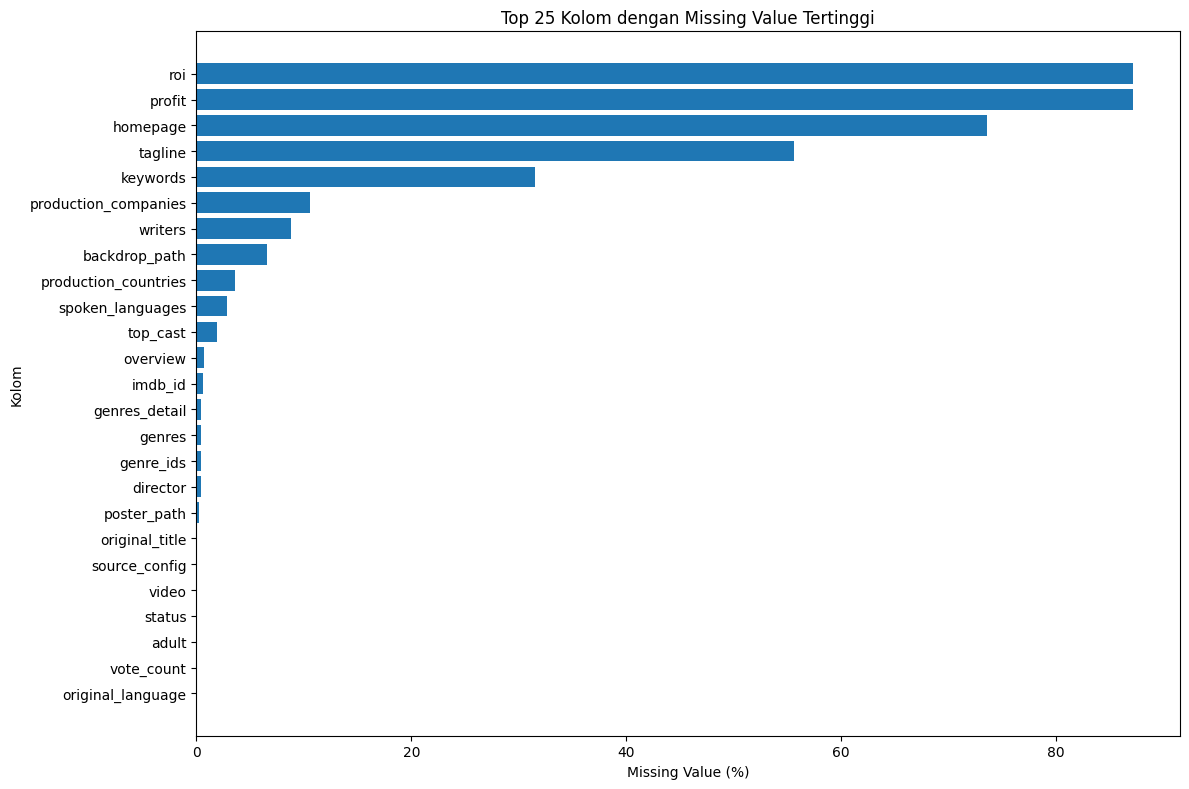

In [15]:
top_missing_pd = missing_pd.head(25).sort_values("missing_pct", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(top_missing_pd["column"], top_missing_pd["missing_pct"])
plt.title("Top 25 Kolom dengan Missing Value Tertinggi")
plt.xlabel("Missing Value (%)")
plt.ylabel("Kolom")
plt.tight_layout()
save_fig("missing_values_top25.png")
plt.show()

## 16. Cek Nilai Kosong pada Kolom Penting

Cell ini fokus pada kolom penting untuk sistem rekomendasi:

- `title`
- `overview`
- `release_date`
- `genres`
- `director`
- `top_cast`
- `keywords`

Kolom-kolom ini penting karena nanti bisa dipakai untuk membangun *movie document* dan fitur model rekomendasi.

In [16]:
important_cols = [
    "id", "title", "overview", "release_date", "genres", "genres_detail",
    "director", "writers", "top_cast", "keywords",
    "vote_average", "vote_count", "popularity"
]

existing_important_cols = [c for c in important_cols if c in df.columns]

important_missing_pd = missing_pd[missing_pd["column"].isin(existing_important_cols)].reset_index(drop=True)
important_missing_pd

,column,missing_count,missing_pct
0,keywords,25427,31.50
1,writers,7073,8.76
2,top_cast,1520,1.88
3,overview,548,0.68
4,genres_detail,379,0.47
5,genres,378,0.47
6,director,355,0.44
7,vote_count,0,0.00
8,vote_average,0,0.00
9,popularity,0,0.00


## 17. Cek Nilai Numerik Tidak Wajar

Cell ini mengecek nilai yang secara logika berpotensi bermasalah:

- `runtime <= 0`
- `vote_average < 0` atau `vote_average > 10`
- `vote_count < 0`
- `budget < 0`
- `revenue < 0`

Nilai `budget = 0` dan `revenue = 0` tidak langsung dianggap salah, karena pada TMDB sering berarti data tidak tersedia.

In [17]:
quality_checks = df.agg(
    F.sum(F.when(F.col("runtime") <= 0, 1).otherwise(0)).alias("runtime_lte_0"),
    F.sum(F.when((F.col("vote_average") < 0) | (F.col("vote_average") > 10), 1).otherwise(0)).alias("vote_average_outside_0_10"),
    F.sum(F.when(F.col("vote_count") < 0, 1).otherwise(0)).alias("vote_count_negative"),
    F.sum(F.when(F.col("budget") < 0, 1).otherwise(0)).alias("budget_negative"),
    F.sum(F.when(F.col("revenue") < 0, 1).otherwise(0)).alias("revenue_negative"),
    F.sum(F.when(F.col("release_year") < 1800, 1).otherwise(0)).alias("release_year_too_old"),
    F.sum(F.when(F.col("release_year") > 2030, 1).otherwise(0)).alias("release_year_too_future"),
)

quality_checks.toPandas()

,runtime_lte_0,vote_average_outside_0_10,vote_count_negative,budget_negative,revenue_negative,release_year_too_old,release_year_too_future
0,868,0,0,0,0,0,0


# Bagian C — Analisis Numerik

Bagian ini menganalisis kolom numerik utama seperti `popularity`, `vote_average`, `vote_count`, `runtime`, `budget`, dan `revenue`.

## 18. Statistik Deskriptif Kolom Numerik

Cell ini menghitung statistik dasar untuk kolom numerik:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum

Statistik ini membantu melihat skala data dan indikasi awal adanya outlier.

In [18]:
numeric_cols = [
    "popularity", "vote_average", "vote_count", "runtime",
    "budget", "revenue", "profit", "roi",
    "overview_length", "tagline_length", "title_length"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

df.select(numeric_cols).describe().toPandas()

,summary,popularity,vote_average,vote_count,runtime,budget,revenue,profit,roi,overview_length,tagline_length,title_length
0,count,80713,80713,80713,80712,80712,80712,10328,10328,80713,80713,80713
1,mean,1.2265391523050817,6.006208516595878,302.1164248634049,94.06892407572604,3724498.0820819703,9691389.065231936,4.413527655451201E7,1871.0350363480834,288.0976174841723,17.974254457150646,16.94000966387075
2,stddev,6.910471829176529,1.0786042640254128,1359.453758899483,31.42404453531016,1.687012003441743E7,6.324543242727118E7,1.3700061277468508E8,117317.82255267548,175.47283183575044,25.13564413074194,10.096499850578676
3,min,0.0,1.2,10,0.0,0.0,0.0,-2.49219154E8,-0.9999998777211926,0,0,0
4,max,881.8242,10.0,39973,999.0,4.899E8,2.923706026E9,2.686706026E9,1.0933336166666666E7,1000,256,135


## 19. Quantile Kolom Numerik

Cell ini menghitung quantile agar distribusi data lebih mudah dipahami.

Quantile yang digunakan:
- 0%
- 1%
- 5%
- 25%
- 50%
- 75%
- 95%
- 99%
- 100%

Quantile lebih informatif daripada mean jika data sangat miring atau memiliki outlier.

In [19]:
quantile_probs = [0.0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]

quantile_rows = []
for c in numeric_cols:
    try:
        qs = df.select(c).na.drop().approxQuantile(c, quantile_probs, 0.01)
        row = {"column": c}
        for p, q in zip(quantile_probs, qs):
            row[f"q{int(p*100):02d}"] = q
        quantile_rows.append(row)
    except Exception as e:
        print(f"Gagal menghitung quantile untuk {c}: {e}")

quantile_pd = pd.DataFrame(quantile_rows)
quantile_pd

,column,q00,q01,q05,q25,q50,q75,q95,q99,q100
0,popularity,0.0,0.0,1.367000e-01,3.096000e-01,5.520000e-01,1.048000e+00,3.263200e+00,8.818242e+02,8.818242e+02
1,vote_average,1.2,1.2,4.000000e+00,5.333000e+00,6.100000e+00,6.745000e+00,7.522000e+00,1.000000e+01,1.000000e+01
2,vote_count,10.0,10.0,1.000000e+01,1.500000e+01,3.000000e+01,9.200000e+01,9.360000e+02,3.997300e+04,3.997300e+04
3,runtime,0.0,0.0,2.700000e+01,8.500000e+01,9.400000e+01,1.060000e+02,1.370000e+02,9.990000e+02,9.990000e+02
4,budget,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+07,4.899000e+08,4.899000e+08
5,revenue,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.434232e+07,2.923706e+09,2.923706e+09
6,profit,-249219154.0,-249219154.0,-1.991221e+07,-3.968605e+06,2.919570e+06,3.300000e+07,2.106506e+08,2.686706e+09,2.686706e+09
7,roi,-1.0,-1.0,-9.640408e-01,-5.623234e-01,4.920088e-01,2.359643e+00,9.137141e+00,1.093334e+07,1.093334e+07
8,overview_length,0.0,0.0,9.300000e+01,1.560000e+02,2.370000e+02,3.720000e+02,6.200000e+02,1.000000e+03,1.000000e+03
9,tagline_length,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,6.500000e+01,2.560000e+02,2.560000e+02


## 20. Distribusi Rating Film

Cell ini membuat histogram untuk `vote_average`.

Karena rating biasanya berada pada rentang 0 sampai 10, distribusi ini membantu melihat apakah rating film cenderung rendah, sedang, atau tinggi.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_vote_average.png


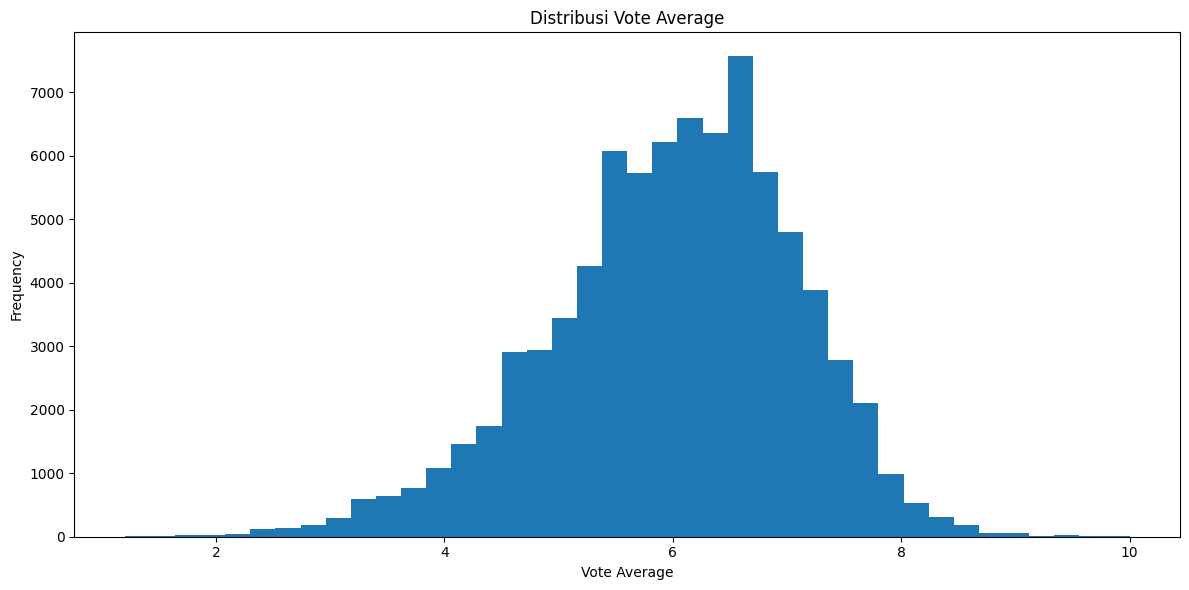

In [20]:
rating_pd = df.select("vote_average").dropna().toPandas()
plot_hist_from_pandas(
    rating_pd,
    "vote_average",
    "Distribusi Vote Average",
    bins=40,
    xlabel="Vote Average",
    filename="distribution_vote_average.png"
)

## 21. Distribusi Jumlah Vote

Cell ini menganalisis `vote_count`.

Karena jumlah vote biasanya sangat timpang, visualisasi memakai `log1p(vote_count)` agar film dengan vote sangat besar tidak mendominasi grafik.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_log_vote_count.png


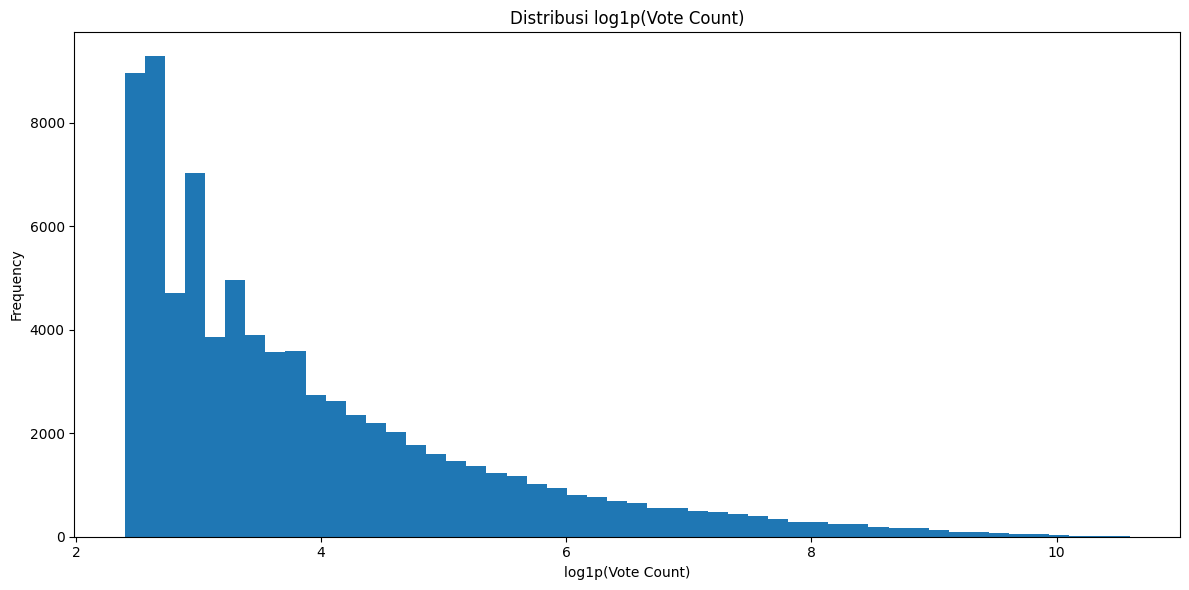

In [21]:
vote_count_pd = (
    df.select("vote_count")
    .dropna()
    .withColumn("log_vote_count", F.log1p("vote_count"))
    .toPandas()
)

plot_hist_from_pandas(
    vote_count_pd,
    "log_vote_count",
    "Distribusi log1p(Vote Count)",
    bins=50,
    xlabel="log1p(Vote Count)",
    filename="distribution_log_vote_count.png"
)

## 22. Distribusi Popularity

Cell ini menganalisis skor `popularity`.

Sama seperti vote count, popularity biasanya memiliki distribusi yang miring ke kanan, sehingga digunakan transformasi `log1p`.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_log_popularity.png


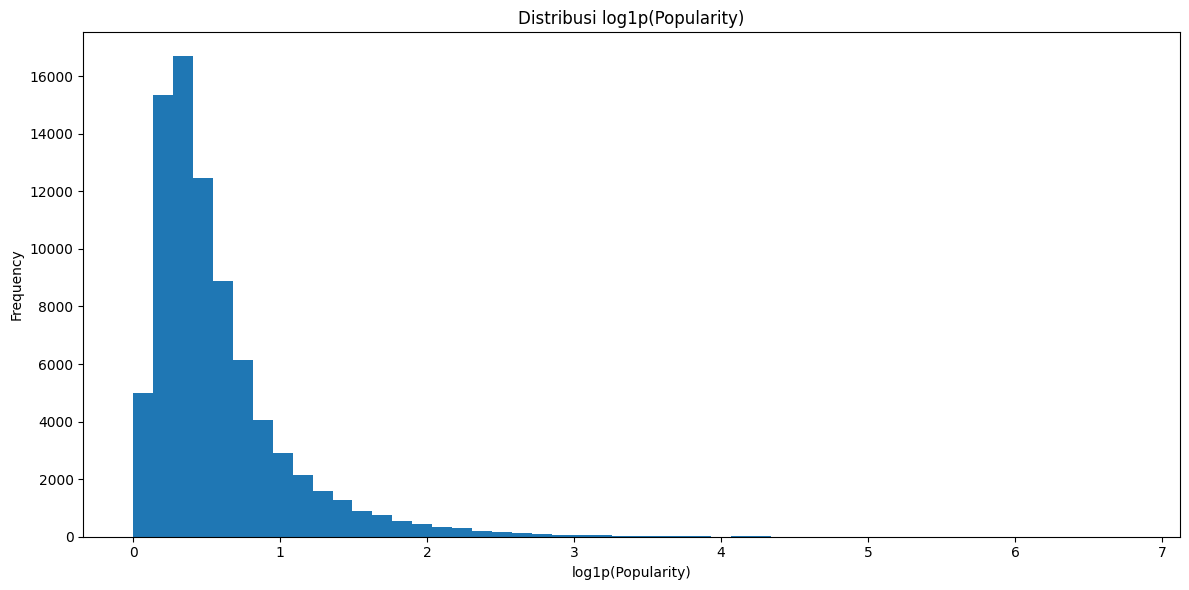

In [22]:
popularity_pd = (
    df.select("popularity")
    .dropna()
    .withColumn("log_popularity", F.log1p("popularity"))
    .toPandas()
)

plot_hist_from_pandas(
    popularity_pd,
    "log_popularity",
    "Distribusi log1p(Popularity)",
    bins=50,
    xlabel="log1p(Popularity)",
    filename="distribution_log_popularity.png"
)

## 23. Distribusi Runtime

Cell ini melihat durasi film dalam menit.

Analisis runtime berguna untuk:
- Mendeteksi film dengan durasi tidak wajar.
- Membuat fitur kategori durasi.
- Memahami karakteristik dataset film.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_runtime.png


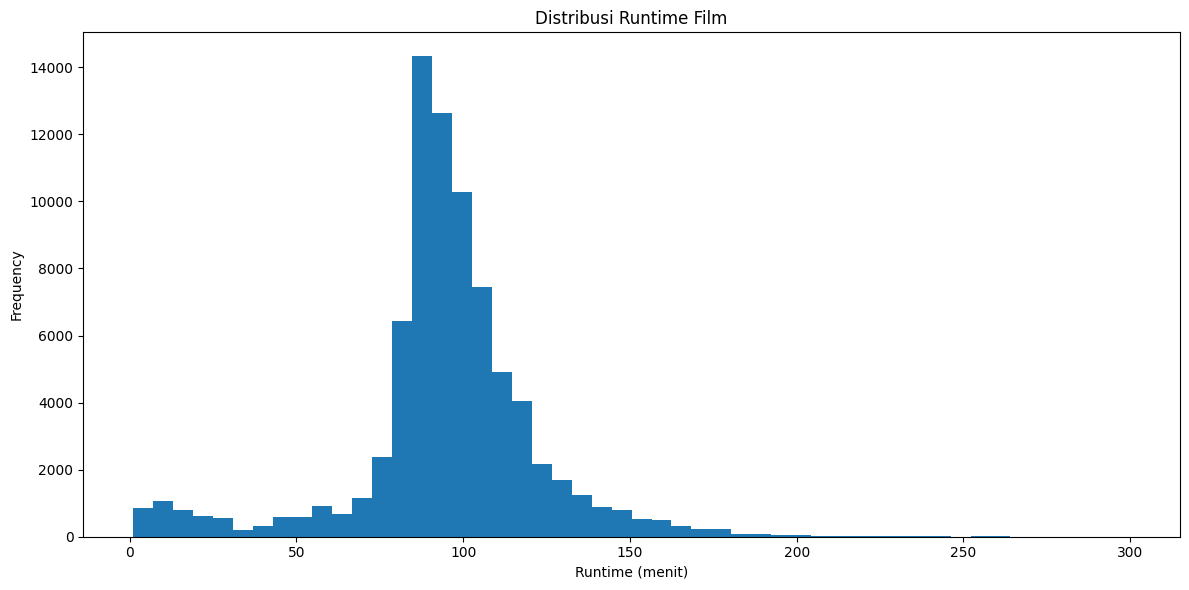

In [23]:
runtime_pd = (
    df.filter((F.col("runtime").isNotNull()) & (F.col("runtime") > 0) & (F.col("runtime") <= 300))
    .select("runtime")
    .toPandas()
)

plot_hist_from_pandas(
    runtime_pd,
    "runtime",
    "Distribusi Runtime Film",
    bins=50,
    xlabel="Runtime (menit)",
    filename="distribution_runtime.png"
)

## 24. Kategori Runtime

Cell ini membuat kategori durasi film:

- `short`: kurang dari 60 menit
- `standard`: 60–120 menit
- `long`: 121–180 menit
- `very_long`: lebih dari 180 menit

Kategori ini membantu membaca pola data secara lebih mudah.

In [24]:
df = (
    df
    .withColumn(
        "runtime_category",
        F.when(F.col("runtime").isNull(), "unknown")
        .when(F.col("runtime") <= 0, "invalid")
        .when(F.col("runtime") < 60, "short")
        .when(F.col("runtime") <= 120, "standard")
        .when(F.col("runtime") <= 180, "long")
        .otherwise("very_long")
    )
).cache()

runtime_category_pd = (
    df.groupBy("runtime_category")
    .agg(F.count("*").alias("count"))
    .orderBy(F.desc("count"))
    .toPandas()
)

runtime_category_pd

,runtime_category,count
0,standard,64669
1,long,8580
2,short,6103
3,invalid,868
4,very_long,492
5,unknown,1


## 25. Visualisasi Kategori Runtime

Cell ini menampilkan jumlah film pada setiap kategori runtime.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\runtime_category_distribution.png


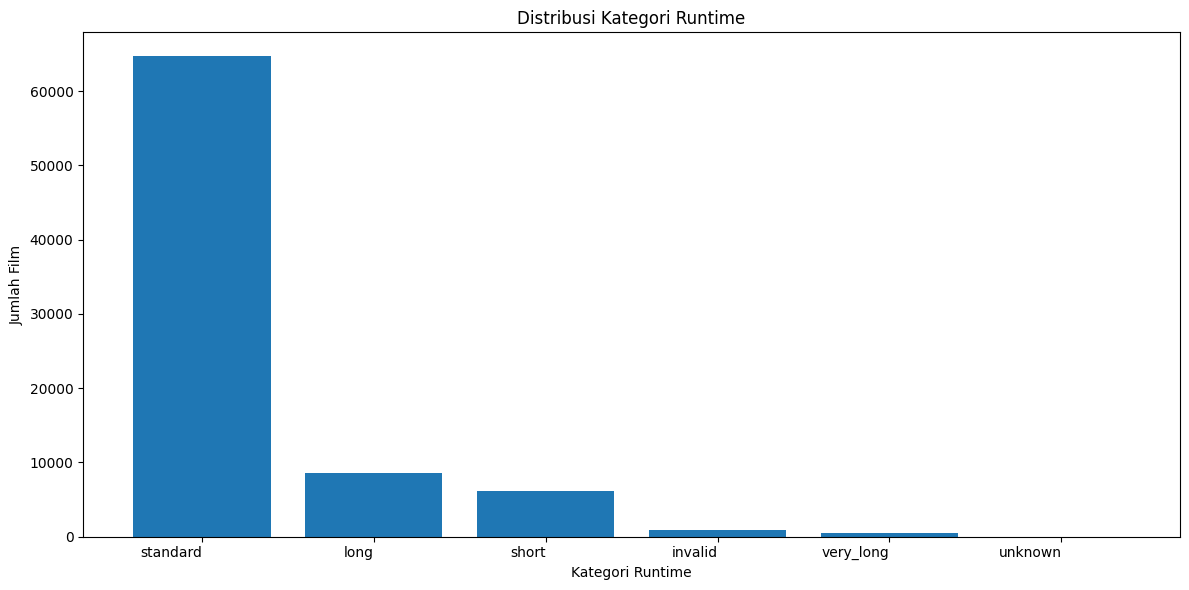

In [25]:
plot_bar(
    runtime_category_pd,
    "runtime_category",
    "count",
    "Distribusi Kategori Runtime",
    xlabel="Kategori Runtime",
    ylabel="Jumlah Film",
    rotation=0,
    filename="runtime_category_distribution.png"
)

# Bagian D — Analisis Waktu Rilis

Bagian ini menganalisis film berdasarkan tahun, dekade, dan bulan rilis.

## 26. Jumlah Film per Tahun Rilis

Cell ini menghitung jumlah film berdasarkan `release_year`.

Tujuannya:
- Melihat periode paling banyak film.
- Mengecek apakah scraping sudah menjangkau tahun yang diharapkan.
- Melihat bias dataset terhadap film modern.

In [26]:
yearly_count_pd = (
    df.filter(F.col("release_year").isNotNull())
    .groupBy("release_year")
    .agg(F.count("*").alias("movie_count"))
    .orderBy("release_year")
    .toPandas()
)

yearly_count_pd.head(), yearly_count_pd.tail()

(   release_year  movie_count
 0          1980          659
 1          1981          658
 2          1982          657
 3          1983          705
 4          1984          684,
     release_year  movie_count
 42          2022         3045
 43          2023         2890
 44          2024         2389
 45          2025         1745
 46          2026          386)

## 27. Visualisasi Jumlah Film per Tahun

Cell ini membuat line chart jumlah film per tahun.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\movies_per_year.png


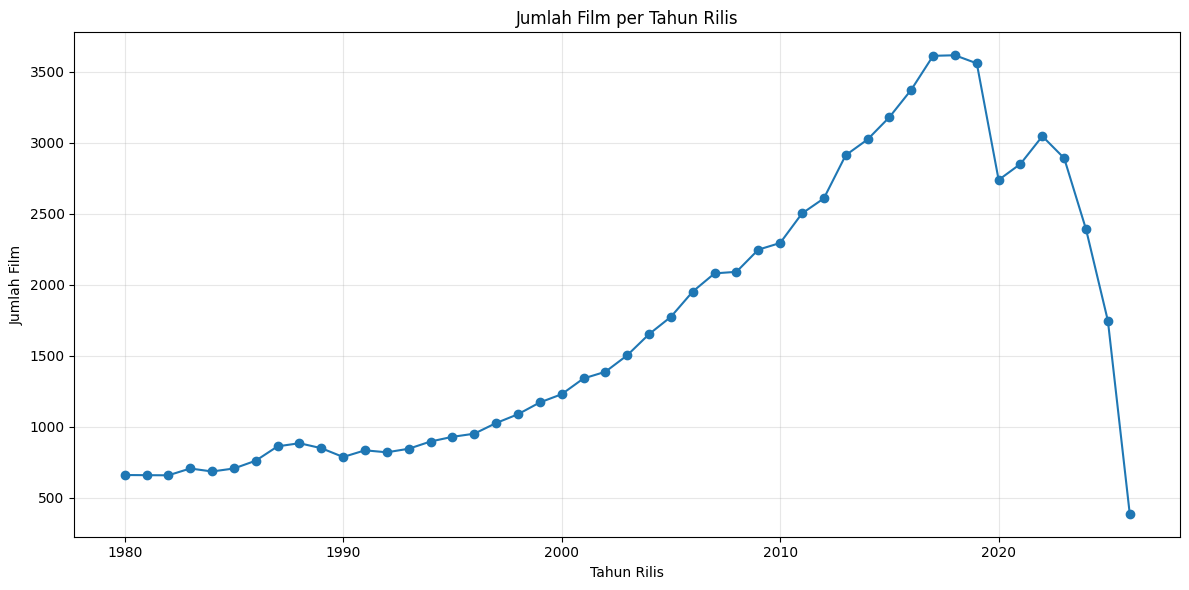

In [27]:
plot_line(
    yearly_count_pd,
    "release_year",
    "movie_count",
    "Jumlah Film per Tahun Rilis",
    xlabel="Tahun Rilis",
    ylabel="Jumlah Film",
    filename="movies_per_year.png"
)

## 28. Jumlah Film per Dekade

Cell ini menghitung jumlah film berdasarkan dekade.

Analisis dekade sering lebih stabil daripada tahun karena mengurangi fluktuasi kecil antar tahun.

In [28]:
decade_count_pd = (
    df.filter(F.col("release_decade").isNotNull())
    .groupBy("release_decade")
    .agg(F.count("*").alias("movie_count"))
    .orderBy("release_decade")
    .toPandas()
)

decade_count_pd

,release_decade,movie_count
0,1980,7420
1,1990,9337
2,2000,17245
3,2010,30669
4,2020,16042


## 29. Visualisasi Jumlah Film per Dekade

Cell ini menampilkan distribusi film berdasarkan dekade.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\movies_per_decade.png


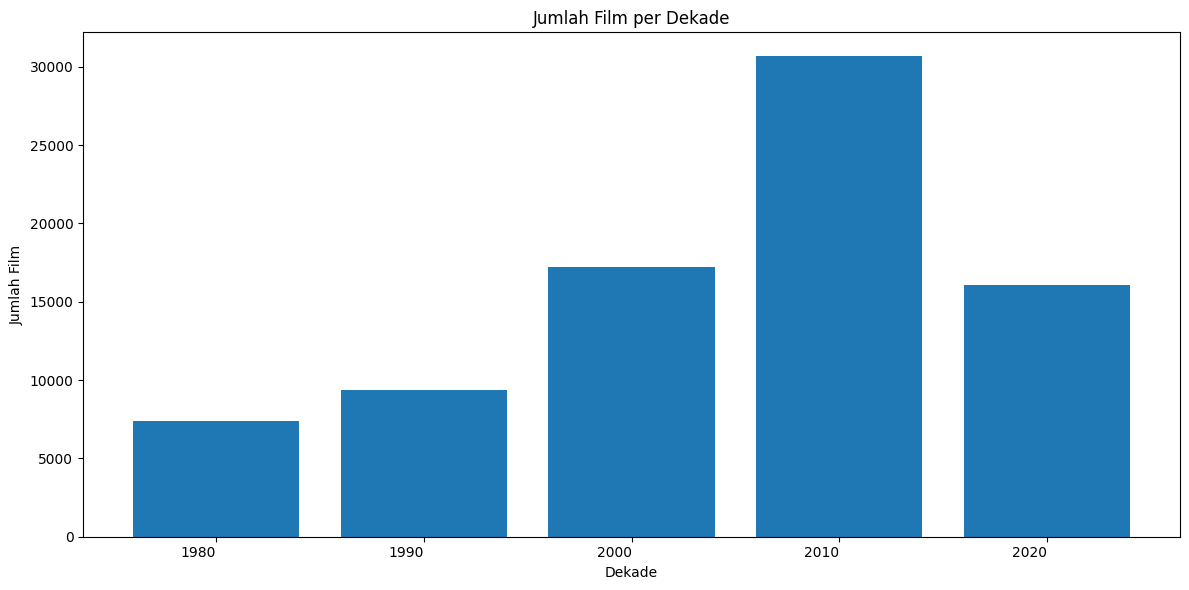

In [29]:
plot_bar(
    decade_count_pd,
    "release_decade",
    "movie_count",
    "Jumlah Film per Dekade",
    xlabel="Dekade",
    ylabel="Jumlah Film",
    rotation=0,
    filename="movies_per_decade.png"
)

## 30. Pola Bulan Rilis

Cell ini menghitung jumlah film berdasarkan bulan rilis.

Analisis ini bisa menunjukkan apakah ada bulan tertentu yang dominan dalam dataset.

In [30]:
monthly_count_pd = (
    df.filter(F.col("release_month").isNotNull())
    .groupBy("release_month")
    .agg(F.count("*").alias("movie_count"))
    .orderBy("release_month")
    .toPandas()
)

monthly_count_pd

,release_month,movie_count
0,1,7121
1,2,5824
2,3,6728
3,4,6283
4,5,5626
5,6,5849
6,7,4978
7,8,6223
8,9,8615
9,10,9220


## 31. Visualisasi Pola Bulan Rilis

Cell ini membuat bar chart jumlah film per bulan rilis.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\movies_per_release_month.png


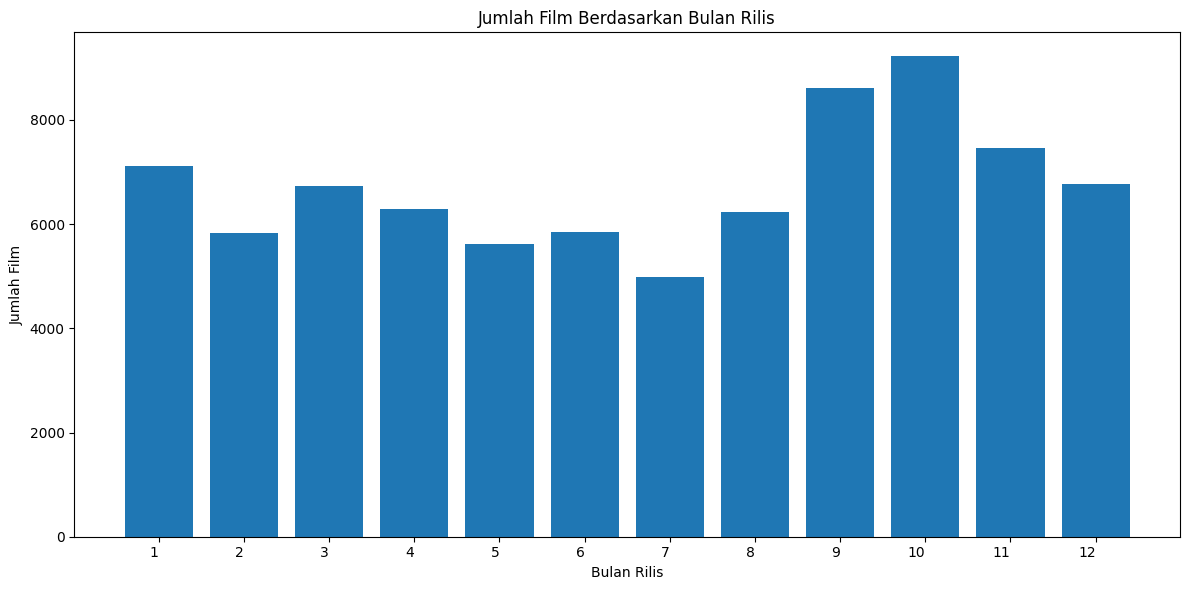

In [31]:
plot_bar(
    monthly_count_pd,
    "release_month",
    "movie_count",
    "Jumlah Film Berdasarkan Bulan Rilis",
    xlabel="Bulan Rilis",
    ylabel="Jumlah Film",
    rotation=0,
    filename="movies_per_release_month.png"
)

# Bagian E — Analisis Genre

Bagian ini menganalisis genre film. Genre sangat penting karena akan menjadi salah satu fitur utama dalam model rekomendasi.

## 32. Membuat Tabel Genre Exploded

Cell ini memecah kolom `genres_detail` atau `genres` menjadi satu baris per genre.

Jika `genres_detail` tersedia, kolom itu dipakai karena berasal dari enrichment detail. Jika tidak, notebook memakai kolom `genres`.

In [32]:
genre_source_col = "genres_detail" if "genres_detail" in df.columns else "genres"

genre_df = (
    df
    .select("id", "title", "release_year", "vote_average", "vote_count", "popularity", F.col(genre_source_col).alias("genre_text"))
    .withColumn("genre", F.explode(F.split(F.coalesce(F.col("genre_text"), F.lit("")), r"\s*\|\s*|\s*,\s*")))
    .withColumn("genre", F.trim(F.col("genre")))
    .filter(F.length("genre") > 0)
    .cache()
)

genre_df.show(10, truncate=False)
print("Jumlah baris genre exploded:", genre_df.count())

+------+------------------------+------------+------------+----------+----------+------------------------------+---------------+
|id    |title                   |release_year|vote_average|vote_count|popularity|genre_text                    |genre          |
+------+------------------------+------------+------------+----------+----------+------------------------------+---------------+
|8738  |The Final Countdown     |1980        |6.637       |667       |3.1869    |War | Action | Science Fiction|War            |
|8738  |The Final Countdown     |1980        |6.637       |667       |3.1869    |War | Action | Science Fiction|Action         |
|8738  |The Final Countdown     |1980        |6.637       |667       |3.1869    |War | Action | Science Fiction|Science Fiction|
|292824|Secrets of a French Maid|1980        |5.819       |36        |1.6089    |Comedy                        |Comedy         |
|41377 |Clan of the White Lotus |1980        |6.656       |48        |1.3433    |Action | Drama  

## 33. Top Genre Berdasarkan Jumlah Film

Cell ini menghitung genre yang paling sering muncul.

In [33]:
top_genres_pd = (
    genre_df.groupBy("genre")
    .agg(F.countDistinct("id").alias("movie_count"))
    .orderBy(F.desc("movie_count"))
    .limit(25)
    .toPandas()
)

top_genres_pd

,genre,movie_count
0,Drama,35308
1,Comedy,25811
2,Thriller,14895
3,Romance,12399
4,Action,11532
5,Horror,10982
6,Crime,8232
7,Documentary,7233
8,TV Movie,6634
9,Family,5872


## 34. Visualisasi Top Genre

Cell ini menampilkan 20 genre teratas berdasarkan jumlah film.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_genres.png


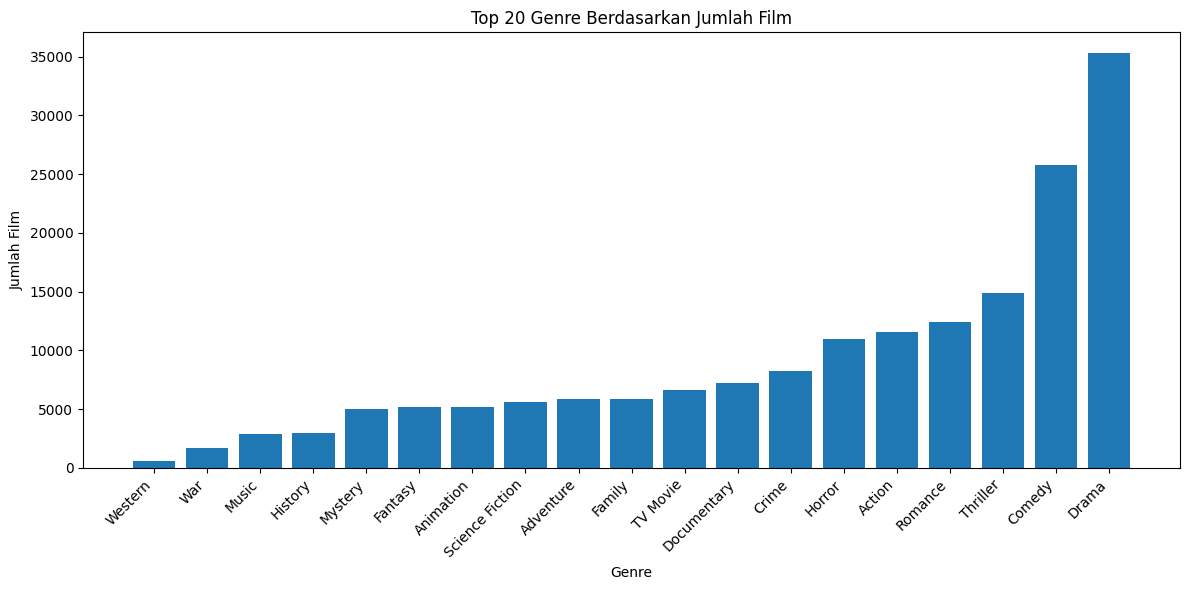

In [34]:
plot_bar(
    top_genres_pd.head(20).sort_values("movie_count", ascending=True),
    "genre",
    "movie_count",
    "Top 20 Genre Berdasarkan Jumlah Film",
    xlabel="Genre",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_genres.png"
)

## 35. Statistik Rating dan Popularity per Genre

Cell ini menghitung rata-rata rating, median vote, dan popularity per genre.

Agar hasil lebih stabil, genre dengan jumlah film terlalu sedikit bisa difilter.

In [35]:
genre_stats_pd = (
    genre_df.groupBy("genre")
    .agg(
        F.countDistinct("id").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity"),
    )
    .filter(F.col("movie_count") >= 100)
    .orderBy(F.desc("avg_vote_average"))
    .toPandas()
)

genre_stats_pd.head(30)

,genre,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,Documentary,7233,6.815537,47.741186,0.463810
1,Music,2908,6.706653,184.404746,1.035330
2,Animation,5214,6.653519,456.874952,1.782988
3,History,2968,6.570144,338.214960,1.241713
4,War,1707,6.368787,422.206796,1.347625
5,Family,5872,6.322699,506.482119,1.666327
6,Drama,35308,6.142028,264.927695,1.153030
7,Fantasy,5191,6.126338,677.002504,2.182199
8,Adventure,5841,6.120412,1075.141243,2.631352
9,TV Movie,6634,6.076395,50.150889,0.652463


## 36. Genre dengan Rata-rata Rating Tertinggi

Cell ini menampilkan genre dengan rata-rata rating tertinggi, tetapi hanya untuk genre yang memiliki cukup banyak film.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_genres_by_rating.png


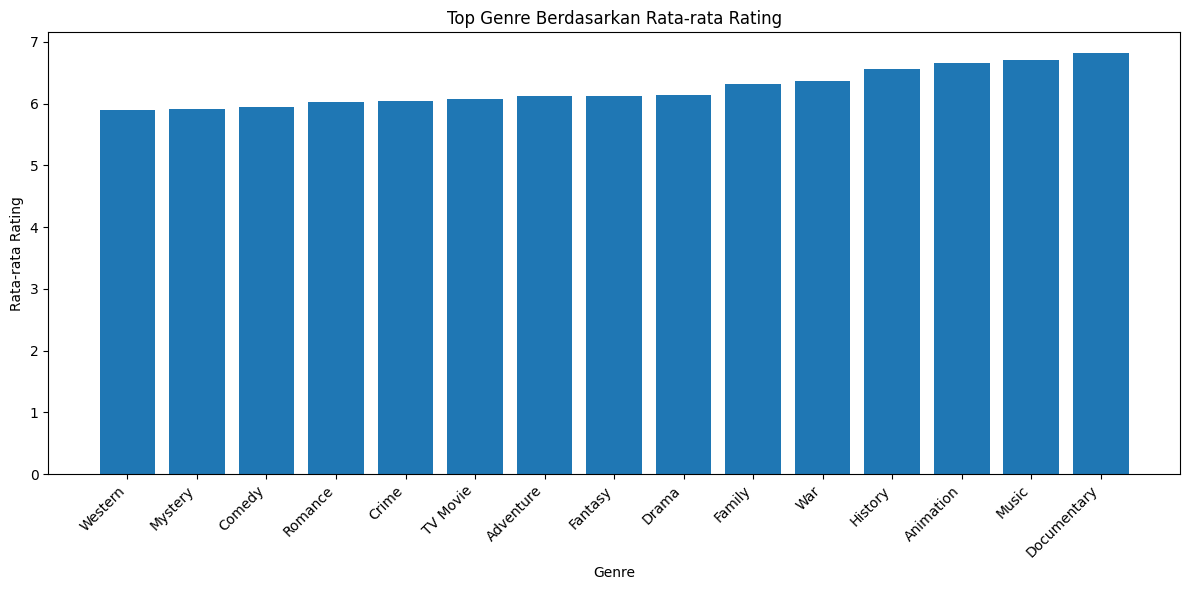

In [36]:
top_genre_rating_pd = genre_stats_pd.sort_values("avg_vote_average", ascending=False).head(15)

plot_bar(
    top_genre_rating_pd.sort_values("avg_vote_average", ascending=True),
    "genre",
    "avg_vote_average",
    "Top Genre Berdasarkan Rata-rata Rating",
    xlabel="Genre",
    ylabel="Rata-rata Rating",
    rotation=45,
    filename="top_genres_by_rating.png"
)

## 37. Perkembangan Genre per Dekade

Cell ini membuat tabel jumlah film per kombinasi `release_decade` dan `genre`.

Tabel ini berguna untuk melihat genre mana yang meningkat atau menurun pada tiap dekade.

In [73]:
genre_decade_pd = (
    genre_df.join(df.select("id", "release_decade"), on="id", how="left")
    .filter(F.col("release_decade").isNotNull())
    .groupBy("release_decade", "genre")
    .agg(F.countDistinct("id").alias("movie_count"))
    .orderBy("release_decade", F.desc("movie_count"))
    .toPandas()
)

genre_decade_pd.head(1000)

,release_decade,genre,movie_count
0,1980,Drama,3032
1,1980,Comedy,2622
2,1980,Horror,1249
3,1980,Action,1244
4,1980,Thriller,1016
...,...,...,...
90,2020,Animation,954
91,2020,History,717
92,2020,Music,630
93,2020,War,319


# Bagian F — Analisis Bahasa, Negara, dan Produksi

Bagian ini menganalisis bahasa asli, bahasa yang digunakan, negara produksi, dan perusahaan produksi.

## 38. Distribusi Bahasa Asli Film

Cell ini menghitung bahasa asli yang paling banyak muncul pada dataset.

In [38]:
language_pd = (
    df.groupBy("original_language")
    .agg(F.count("*").alias("movie_count"))
    .orderBy(F.desc("movie_count"))
    .limit(25)
    .toPandas()
)

language_pd

,original_language,movie_count
0,en,43329
1,fr,6083
2,es,4262
3,ja,3599
4,it,2862
5,de,2313
6,hi,1625
7,ko,1536
8,ru,1455
9,zh,1400


## 39. Visualisasi Bahasa Asli Teratas

Cell ini menampilkan 20 bahasa asli film terbanyak.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_original_languages.png


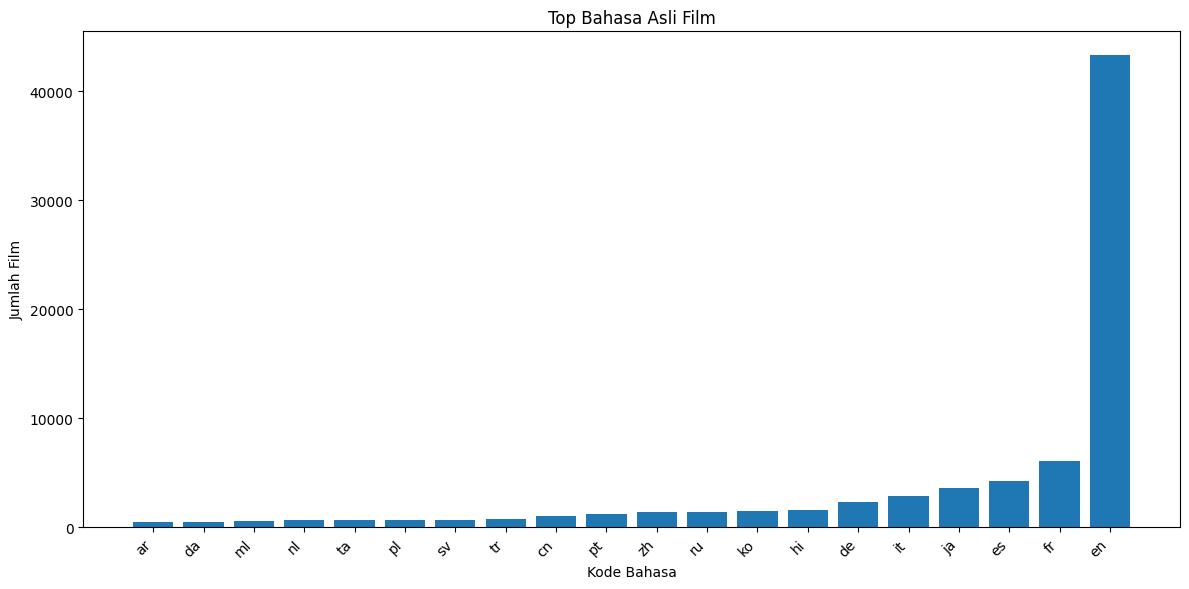

In [39]:
plot_bar(
    language_pd.head(20).sort_values("movie_count", ascending=True),
    "original_language",
    "movie_count",
    "Top Bahasa Asli Film",
    xlabel="Kode Bahasa",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_original_languages.png"
)

## 40. Statistik Rating Berdasarkan Bahasa

Cell ini menghitung rata-rata rating, vote count, dan popularity berdasarkan bahasa asli film.

Filter `movie_count >= 100` digunakan agar bahasa dengan film sangat sedikit tidak membuat interpretasi bias.

In [40]:
language_stats_pd = (
    df.groupBy("original_language")
    .agg(
        F.count("*").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity")
    )
    .filter(F.col("movie_count") >= 100)
    .orderBy(F.desc("avg_vote_average"))
    .toPandas()
)

language_stats_pd.head(30)

,original_language,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,ro,232,6.584573,35.331897,0.325844
1,ja,3599,6.559236,136.294804,1.419628
2,ko,1536,6.540412,139.692057,1.608623
3,id,206,6.525015,72.082524,0.994946
4,sr,121,6.509628,66.388430,0.610032
5,uk,111,6.498703,49.558559,0.519255
6,hu,198,6.391343,47.969697,0.429227
7,ml,634,6.387049,24.015773,0.712173
8,zh,1400,6.386266,77.222143,1.444033
9,fa,236,6.367195,67.449153,0.450605


## 41. Membuat Tabel Negara Produksi Exploded

Cell ini memecah kolom `production_countries` menjadi satu baris per negara.

In [41]:
country_df = (
    df
    .select("id", "title", "vote_average", "vote_count", "popularity", "production_countries")
    .withColumn("production_country", F.explode(F.split(F.coalesce(F.col("production_countries"), F.lit("")), r"\s*\|\s*")))
    .withColumn("production_country", F.trim(F.col("production_country")))
    .filter(F.length("production_country") > 0)
    .cache()
)

country_df.show(10, truncate=False)

+------+----------------------------+------------+----------+----------+------------------------+------------------------+
|id    |title                       |vote_average|vote_count|popularity|production_countries    |production_country      |
+------+----------------------------+------------+----------+----------+------------------------+------------------------+
|8738  |The Final Countdown         |6.637       |667       |3.1869    |United States of America|United States of America|
|292824|Secrets of a French Maid    |5.819       |36        |1.6089    |Switzerland             |Switzerland             |
|41377 |Clan of the White Lotus     |6.656       |48        |1.3433    |Hong Kong               |Hong Kong               |
|91561 |Deadline                    |5.2         |29        |0.8531    |Canada                  |Canada                  |
|141198|Los energéticos             |6.1         |15        |0.8466    |Spain                   |Spain                   |
|79989 |Bride of

## 42. Top Negara Produksi

Cell ini menghitung negara produksi yang paling sering muncul.

In [42]:
top_countries_pd = (
    country_df.groupBy("production_country")
    .agg(F.countDistinct("id").alias("movie_count"))
    .orderBy(F.desc("movie_count"))
    .limit(25)
    .toPandas()
)

top_countries_pd

,production_country,movie_count
0,United States of America,32800
1,France,8589
2,United Kingdom,7112
3,Canada,5347
4,Germany,4550
5,Japan,4050
6,Italy,3790
7,India,3602
8,Spain,2626
9,Belgium,1722


## 43. Visualisasi Top Negara Produksi

Cell ini menampilkan 20 negara produksi teratas.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_production_countries.png


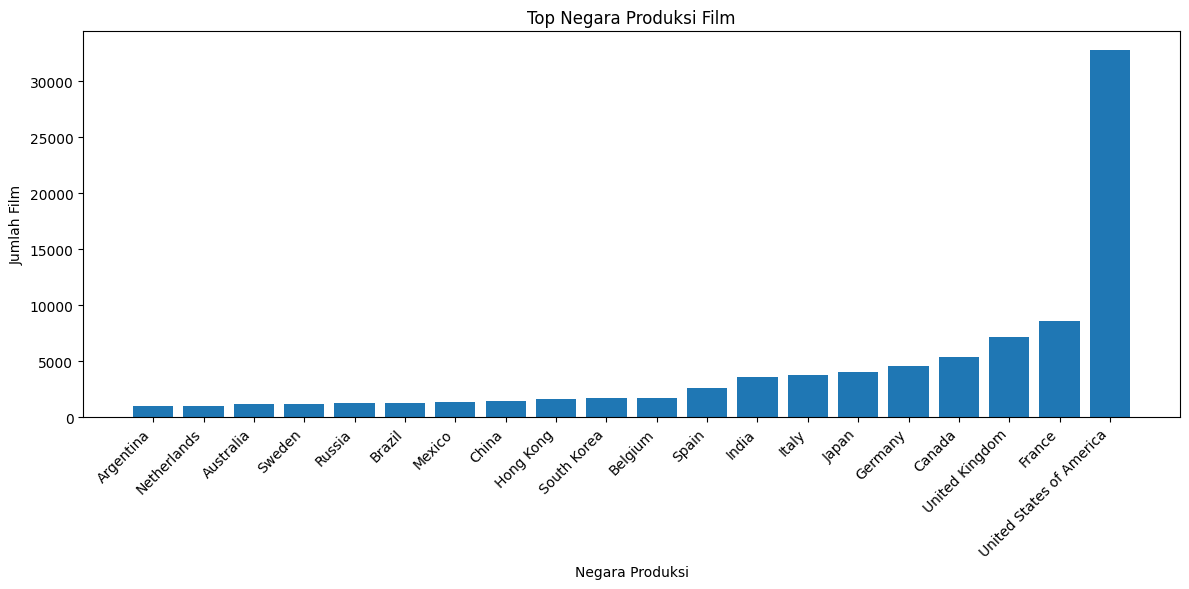

In [43]:
plot_bar(
    top_countries_pd.head(20).sort_values("movie_count", ascending=True),
    "production_country",
    "movie_count",
    "Top Negara Produksi Film",
    xlabel="Negara Produksi",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_production_countries.png"
)

## 44. Top Production Companies

Cell ini memecah kolom `production_companies` dan menampilkan perusahaan produksi yang paling sering muncul.

In [44]:
company_df = (
    df
    .select("id", "title", "production_companies")
    .withColumn("production_company", F.explode(F.split(F.coalesce(F.col("production_companies"), F.lit("")), r"\s*\|\s*")))
    .withColumn("production_company", F.trim(F.col("production_company")))
    .filter(F.length("production_company") > 0)
    .cache()
)

top_companies_pd = (
    company_df.groupBy("production_company")
    .agg(F.countDistinct("id").alias("movie_count"))
    .orderBy(F.desc("movie_count"))
    .limit(25)
    .toPandas()
)

top_companies_pd

,production_company,movie_count
0,Universal Pictures,780
1,Lifetime,760
2,Canal+,697
3,Warner Bros. Pictures,662
4,France 2 Cinéma,622
5,RAI Cinema,565
6,Paramount Pictures,561
7,Columbia Pictures,525
8,France 3 Cinéma,522
9,ARTE,492


# Bagian G — Analisis Cast, Director, Writer, dan Keyword

Bagian ini penting untuk sistem rekomendasi karena nama aktor, sutradara, penulis, dan keyword sering menjadi fitur yang kuat dalam rekomendasi film.

## 45. Top Director Berdasarkan Jumlah Film

Cell ini menghitung sutradara yang paling banyak muncul dalam dataset.

Catatan:
- Jika satu film memiliki lebih dari satu director, cell ini memecah berdasarkan separator `|`.
- Hasil ini bisa dipakai untuk fitur metadata search, misalnya “film oleh Christopher Nolan”.

In [45]:
director_df = (
    df
    .select("id", "title", "vote_average", "vote_count", "popularity", "director")
    .withColumn("director_name", F.explode(F.split(F.coalesce(F.col("director"), F.lit("")), r"\s*\|\s*")))
    .withColumn("director_name", F.trim(F.col("director_name")))
    .filter(F.length("director_name") > 0)
    .cache()
)

top_directors_pd = (
    director_df.groupBy("director_name")
    .agg(
        F.countDistinct("id").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity")
    )
    .orderBy(F.desc("movie_count"))
    .limit(30)
    .toPandas()
)

top_directors_pd

,director_name,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,Fred Olen Ray,106,4.664689,25.443396,0.701011
1,David DeCoteau,99,4.222838,26.777778,0.482239
2,Jim Wynorski,78,4.509615,38.884615,1.067013
3,Takashi Miike,68,6.411897,176.661765,1.156537
4,Wong Jing,61,6.151869,56.622951,1.726670
5,Terry Ingram,60,6.399467,40.433333,0.568473
6,Carlo Vanzina,57,5.171140,127.456140,0.457649
7,Michael Feifer,52,5.102596,33.211538,0.546585
8,Johnnie To,50,6.515300,86.220000,1.521880
9,Steven R. Monroe,49,5.828673,130.428571,1.100584


## 46. Visualisasi Top Director

Cell ini menampilkan 20 sutradara dengan jumlah film terbanyak.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_directors.png


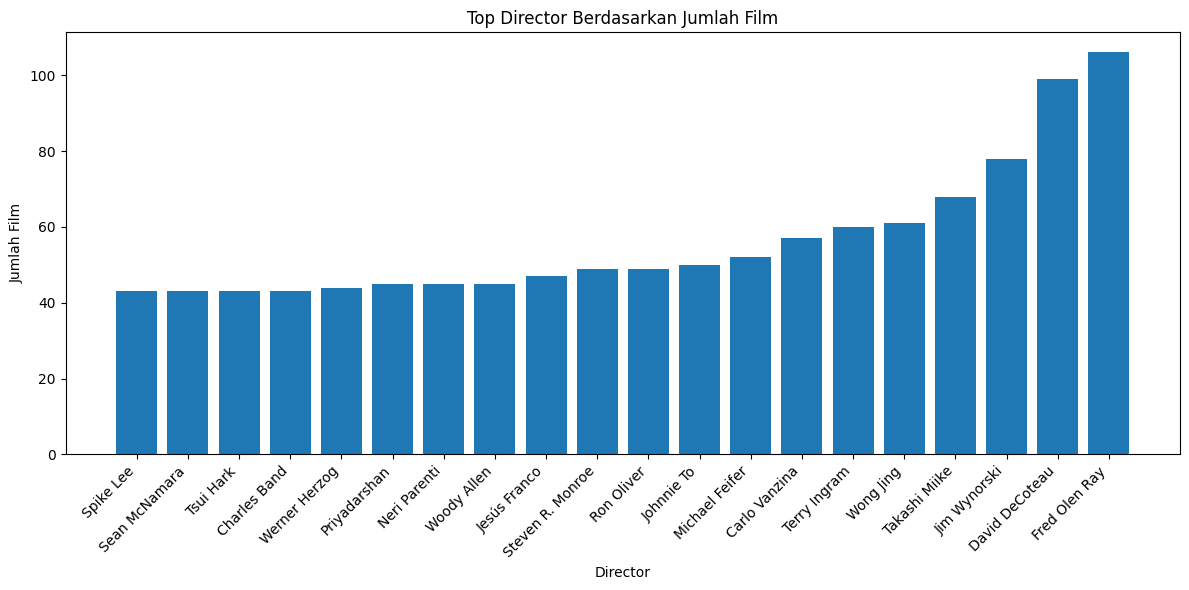

In [46]:
plot_bar(
    top_directors_pd.head(20).sort_values("movie_count", ascending=True),
    "director_name",
    "movie_count",
    "Top Director Berdasarkan Jumlah Film",
    xlabel="Director",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_directors.png"
)

## 47. Director dengan Rata-rata Rating Tinggi

Cell ini menampilkan sutradara dengan rata-rata rating tinggi, tetapi hanya untuk sutradara yang memiliki minimal beberapa film agar hasil tidak terlalu bias.

Kamu bisa mengubah `MIN_DIRECTOR_MOVIES` sesuai kebutuhan.

In [47]:
MIN_DIRECTOR_MOVIES = 5

director_rating_pd = (
    director_df.groupBy("director_name")
    .agg(
        F.countDistinct("id").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity")
    )
    .filter(F.col("movie_count") >= MIN_DIRECTOR_MOVIES)
    .orderBy(F.desc("avg_vote_average"))
    .limit(30)
    .toPandas()
)

director_rating_pd

,director_name,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,Ishi Rudell,9,8.266222,90.000000,1.087589
1,Wayne Isham,6,8.173333,37.000000,0.412317
2,Park Jun-soo,10,8.058300,132.900000,1.444590
3,Costa Botes,5,8.040000,33.200000,0.494260
4,Dick Carruthers,6,8.038167,24.500000,0.255233
5,Alex Coletti,5,8.011800,35.200000,0.416120
6,Beyoncé,9,8.007667,90.333333,0.676133
7,Yann Arthus-Bertrand,6,7.990667,178.833333,1.325400
8,Nick Wickham,9,7.985000,26.333333,0.326967
9,Les Luthiers,5,7.921200,13.800000,0.106160


## 48. Top Cast Berdasarkan Jumlah Film

Cell ini memecah `top_cast` menjadi satu baris per aktor, lalu menghitung aktor yang paling sering muncul.

In [48]:
cast_df = (
    df
    .select("id", "title", "vote_average", "vote_count", "popularity", "top_cast")
    .withColumn("actor_name", F.explode(F.split(F.coalesce(F.col("top_cast"), F.lit("")), r"\s*\|\s*")))
    .withColumn("actor_name", F.trim(F.col("actor_name")))
    .filter(F.length("actor_name") > 0)
    .cache()
)

top_cast_pd = (
    cast_df.groupBy("actor_name")
    .agg(
        F.countDistinct("id").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity")
    )
    .orderBy(F.desc("movie_count"))
    .limit(30)
    .toPandas()
)

top_cast_pd

,actor_name,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,Eric Roberts,223,4.864206,113.713004,0.800534
1,Frank Welker,161,6.939019,530.496894,1.581792
2,Danny Trejo,150,5.063787,347.333333,1.316787
3,Prakash Raj,150,6.095933,40.100000,1.067618
4,Michael Madsen,150,5.072413,718.973333,1.575351
5,Nassar,146,6.078356,43.801370,1.034580
6,Gérard Depardieu,144,5.883167,301.659722,0.956821
7,Samuel L. Jackson,137,6.409642,3488.875912,4.274182
8,Lance Henriksen,130,5.184962,517.384615,1.327338
9,Willem Dafoe,124,6.429976,2358.080645,3.928182


## 49. Visualisasi Top Cast

Cell ini menampilkan 20 aktor yang paling sering muncul pada dataset.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_cast.png


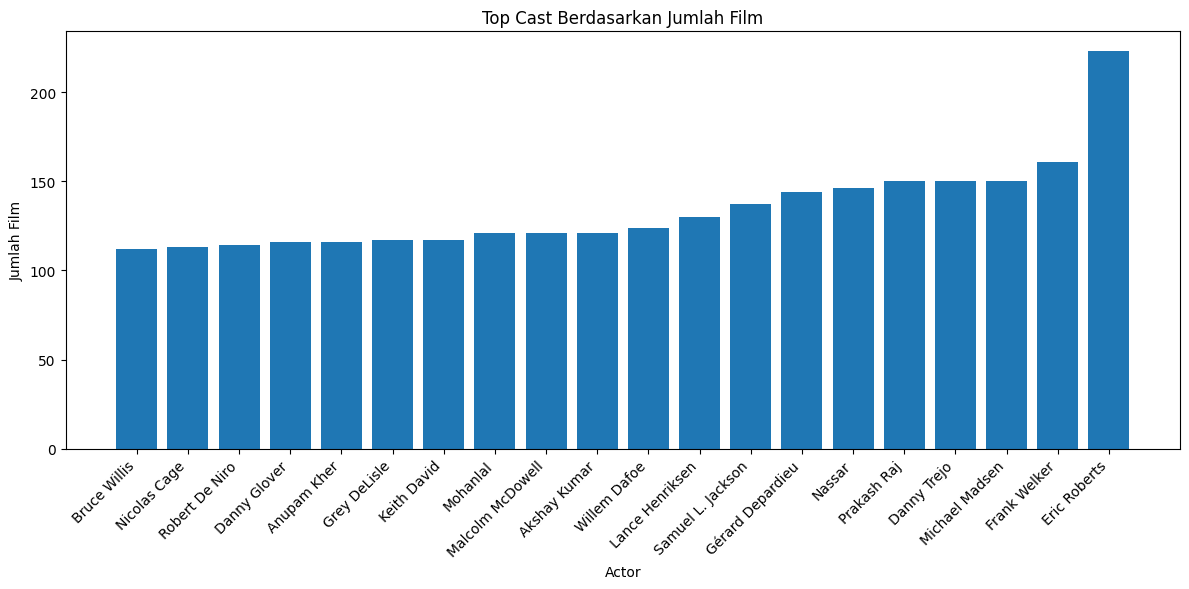

In [49]:
plot_bar(
    top_cast_pd.head(20).sort_values("movie_count", ascending=True),
    "actor_name",
    "movie_count",
    "Top Cast Berdasarkan Jumlah Film",
    xlabel="Actor",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_cast.png"
)

## 50. Top Writers

Cell ini memecah kolom `writers` dan menghitung penulis yang paling sering muncul.

In [50]:
writer_df = (
    df
    .select("id", "title", "vote_average", "vote_count", "popularity", "writers")
    .withColumn("writer_name", F.explode(F.split(F.coalesce(F.col("writers"), F.lit("")), r"\s*\|\s*")))
    .withColumn("writer_name", F.trim(F.col("writer_name")))
    .filter(F.length("writer_name") > 0)
    .cache()
)

top_writers_pd = (
    writer_df.groupBy("writer_name")
    .agg(
        F.countDistinct("id").alias("movie_count"),
        F.avg("vote_average").alias("avg_vote_average"),
        F.avg("vote_count").alias("avg_vote_count"),
        F.avg("popularity").alias("avg_popularity")
    )
    .orderBy(F.desc("movie_count"))
    .limit(30)
    .toPandas()
)

top_writers_pd

,writer_name,movie_count,avg_vote_average,avg_vote_count,avg_popularity
0,Wong Jing,100,6.101176,52.450980,1.735962
1,Peter Sullivan,89,5.300948,57.974138,0.703365
2,Enrico Vanzina,86,5.240616,137.021739,0.423460
3,Jeffrey Schenck,71,5.357972,44.788732,0.635242
4,Bob Kane,67,6.961791,3665.597015,4.801078
5,Carlo Vanzina,66,5.280113,145.792453,0.404820
6,Fred Olen Ray,63,4.702641,30.687500,0.693002
7,Barbara Kymlicka,61,5.791000,40.177419,0.792913
8,Stephen King,61,6.062077,2815.584615,5.167197
9,Per Wahlöö,57,5.748070,26.701754,0.429816


## 51. Top Keywords

Cell ini memecah kolom `keywords` dan menghitung keyword yang paling sering muncul.

Keyword penting untuk model rekomendasi karena biasanya menggambarkan tema film, misalnya:
- `time travel`
- `superhero`
- `revenge`
- `friendship`
- `space`

In [51]:
keyword_df = (
    df
    .select("id", "title", "vote_average", "vote_count", "popularity", "keywords")
    .withColumn("keyword", F.explode(F.split(F.coalesce(F.col("keywords"), F.lit("")), r"\s*\|\s*")))
    .withColumn("keyword", F.trim(F.lower(F.col("keyword"))))
    .filter(F.length("keyword") > 0)
    .cache()
)

top_keywords_pd = (
    keyword_df.groupBy("keyword")
    .agg(F.countDistinct("id").alias("movie_count"))
    .orderBy(F.desc("movie_count"))
    .limit(50)
    .toPandas()
)

top_keywords_pd.head(30)

,keyword,movie_count
0,woman director,4758
1,based on novel or book,3093
2,murder,2143
3,lgbt,1798
4,short film,1766
5,based on true story,1711
6,gay theme,1682
7,christmas,1658
8,biography,1405
9,anime,1221


## 52. Visualisasi Top Keywords

Cell ini menampilkan 25 keyword paling sering muncul.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\top_keywords.png


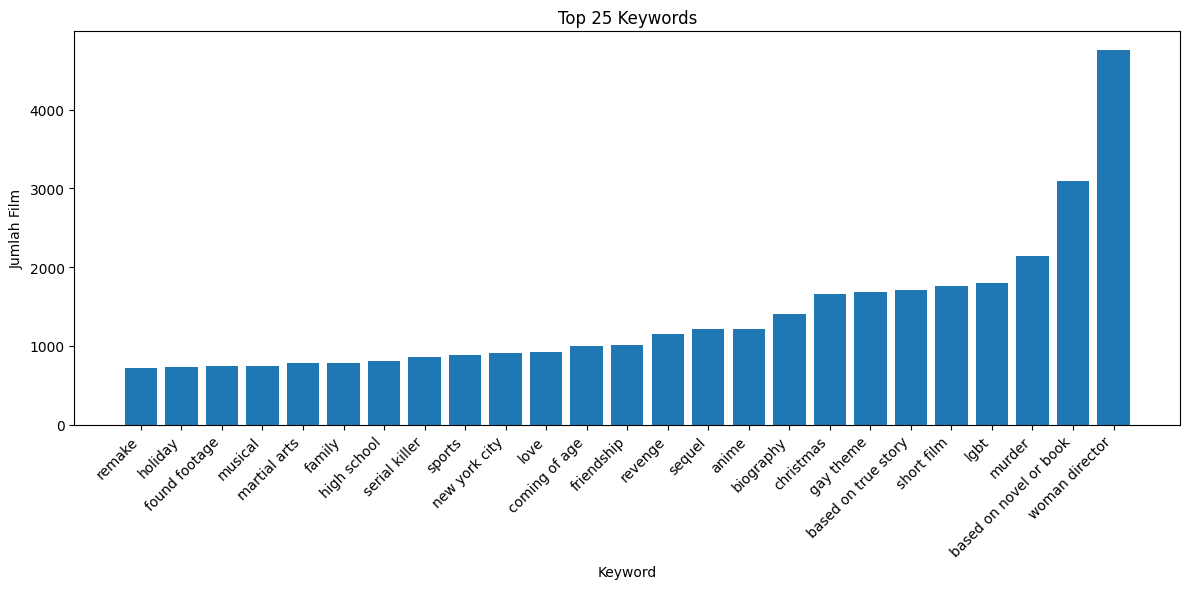

In [52]:
plot_bar(
    top_keywords_pd.head(25).sort_values("movie_count", ascending=True),
    "keyword",
    "movie_count",
    "Top 25 Keywords",
    xlabel="Keyword",
    ylabel="Jumlah Film",
    rotation=45,
    filename="top_keywords.png"
)

# Bagian H — Analisis Budget, Revenue, dan Profit

Bagian ini menganalisis data finansial film. Karena banyak film memiliki `budget = 0` atau `revenue = 0`, analisis dibagi menjadi dua:
- Cek kelengkapan data finansial.
- Analisis hanya pada film yang memiliki budget dan revenue valid.

## 53. Kelengkapan Budget dan Revenue

Cell ini menghitung berapa banyak film yang memiliki budget, revenue, dan keduanya.

In [53]:
financial_availability_pd = df.agg(
    F.count("*").alias("total_movies"),
    F.sum("has_budget").alias("movies_with_budget"),
    F.sum("has_revenue").alias("movies_with_revenue"),
    F.sum("has_budget_revenue").alias("movies_with_budget_and_revenue"),
).toPandas()

financial_availability_pd["budget_pct"] = (
    financial_availability_pd["movies_with_budget"] / financial_availability_pd["total_movies"] * 100
).round(2)
financial_availability_pd["revenue_pct"] = (
    financial_availability_pd["movies_with_revenue"] / financial_availability_pd["total_movies"] * 100
).round(2)
financial_availability_pd["budget_revenue_pct"] = (
    financial_availability_pd["movies_with_budget_and_revenue"] / financial_availability_pd["total_movies"] * 100
).round(2)

financial_availability_pd

,total_movies,movies_with_budget,movies_with_revenue,movies_with_budget_and_revenue,budget_pct,revenue_pct,budget_revenue_pct
0,80713,15994,16830,10328,19.82,20.85,12.8


## 54. Dataset Finansial Valid

Cell ini membuat subset `financial_df`, yaitu film yang memiliki `budget > 0` dan `revenue > 0`.

Subset ini lebih cocok untuk analisis profit dan ROI.

In [54]:
financial_df = (
    df
    .filter((F.col("budget") > 0) & (F.col("revenue") > 0))
    .withColumn("log_budget", F.log1p("budget"))
    .withColumn("log_revenue", F.log1p("revenue"))
    .withColumn("log_profit_abs", F.log1p(F.abs(F.col("profit"))))
    .cache()
)

print("Jumlah film dengan budget & revenue valid:", financial_df.count())
financial_df.select("title", "release_year", "budget", "revenue", "profit", "roi").show(10, truncate=False)

Jumlah film dengan budget & revenue valid: 10328
+--------------------------------+------------+---------+-----------+----------+-------------------+
|title                           |release_year|budget   |revenue    |profit    |roi                |
+--------------------------------+------------+---------+-----------+----------+-------------------+
|The Final Countdown             |1980        |1.2E7    |1.66478E7  |4647800.0 |0.38731666666666664|
|Bilo the Banker                 |1980        |85000.0  |243000.0   |158000.0  |1.8588235294117648 |
|Hardly Working                  |1980        |3400000.0|4.9E7      |4.56E7    |13.411764705882353 |
|Cannibal Holocaust              |1980        |100000.0 |2000000.0  |1900000.0 |19.0               |
|The Fog                         |1980        |1000000.0|2.144883E7 |2.044883E7|20.44883           |
|Cruising                        |1980        |1.1E7    |1.9814523E7|8814523.0 |0.8013202727272727 |
|American Gigolo                 |1980    

## 55. Distribusi Budget dan Revenue

Cell ini membuat histogram `log1p(budget)` dan `log1p(revenue)`.

Transformasi log dipakai karena nilai budget/revenue biasanya sangat timpang.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_log_budget.png


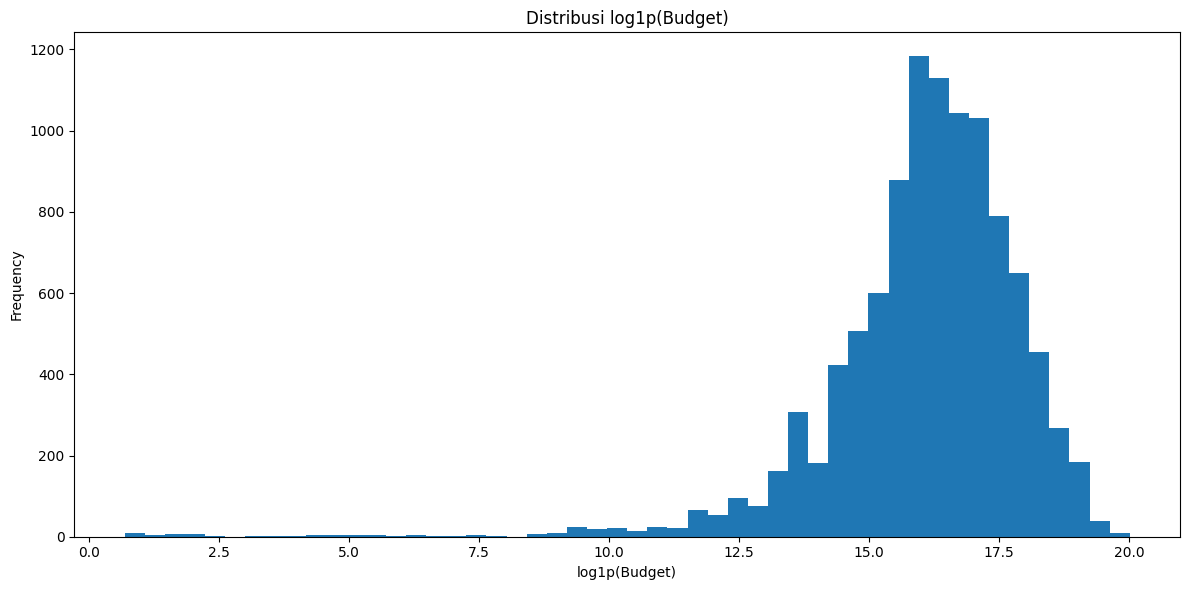

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_log_revenue.png


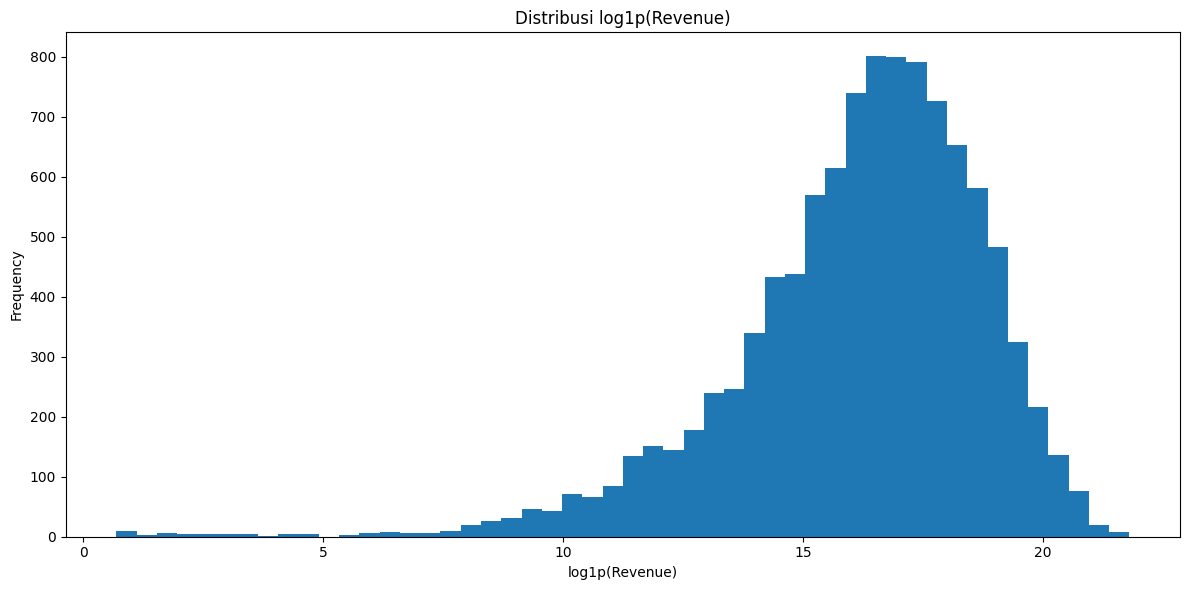

In [55]:
financial_pd = financial_df.select("log_budget", "log_revenue", "profit", "roi").toPandas()

plot_hist_from_pandas(
    financial_pd,
    "log_budget",
    "Distribusi log1p(Budget)",
    bins=50,
    xlabel="log1p(Budget)",
    filename="distribution_log_budget.png"
)

plot_hist_from_pandas(
    financial_pd,
    "log_revenue",
    "Distribusi log1p(Revenue)",
    bins=50,
    xlabel="log1p(Revenue)",
    filename="distribution_log_revenue.png"
)

## 56. Film dengan Revenue Tertinggi

Cell ini menampilkan film dengan pendapatan tertinggi.

In [56]:
top_revenue_pd = (
    financial_df
    .select("id", "title", "release_year", "genres_detail", "budget", "revenue", "profit", "roi", "vote_average", "vote_count", "popularity")
    .orderBy(F.desc("revenue"))
    .limit(20)
    .toPandas()
)

top_revenue_pd

,id,title,release_year,genres_detail,budget,revenue,profit,roi,vote_average,vote_count,popularity
0,19995,Avatar,2009,Science Fiction | Action | Adventure,237000000.0,2.923706e+09,2.686706e+09,11.336312,7.606,34041,44.4028
1,299534,Avengers: Endgame,2019,Adventure | Science Fiction | Action,356000000.0,2.799439e+09,2.443439e+09,6.863593,8.237,27811,31.1830
2,76600,Avatar: The Way of Water,2022,Action | Adventure | Science Fiction,350000000.0,2.353096e+09,2.003096e+09,5.723132,7.594,14173,25.6483
3,597,Titanic,1997,Drama | Romance,200000000.0,2.264162e+09,2.064162e+09,10.320812,7.903,27206,31.8910
4,980477,Ne Zha 2,2025,Animation | Action | Fantasy | Adventure,80000000.0,2.259822e+09,2.179822e+09,27.247780,8.161,708,40.1709
5,140607,Star Wars: The Force Awakens,2015,Adventure | Action | Science Fiction,245000000.0,2.068224e+09,1.823224e+09,7.441729,7.200,20562,10.7750
6,299536,Avengers: Infinity War,2018,Adventure | Action | Science Fiction,300000000.0,2.052415e+09,1.752415e+09,5.841383,8.237,32078,48.0912
7,634649,Spider-Man: No Way Home,2021,Action | Adventure | Science Fiction,200000000.0,2.019207e+09,1.819207e+09,9.096033,7.900,22048,38.9195
8,1084242,Zootopia 2,2025,Action | Adventure | Animation | Comedy | Crime | Family | Mystery,150000000.0,1.868209e+09,1.718209e+09,11.454725,7.662,2925,82.3237
9,1022789,Inside Out 2,2024,Animation | Adventure | Comedy | Family,200000000.0,1.698864e+09,1.498864e+09,7.494319,7.546,6706,29.2564


## 57. Film dengan Profit Tertinggi

Cell ini menampilkan film dengan profit tertinggi.

In [57]:
top_profit_pd = (
    financial_df
    .select("id", "title", "release_year", "genres_detail", "budget", "revenue", "profit", "roi", "vote_average", "vote_count", "popularity")
    .orderBy(F.desc("profit"))
    .limit(20)
    .toPandas()
)

top_profit_pd

,id,title,release_year,genres_detail,budget,revenue,profit,roi,vote_average,vote_count,popularity
0,19995,Avatar,2009,Science Fiction | Action | Adventure,237000000.0,2.923706e+09,2.686706e+09,11.336312,7.606,34041,44.4028
1,299534,Avengers: Endgame,2019,Adventure | Science Fiction | Action,356000000.0,2.799439e+09,2.443439e+09,6.863593,8.237,27811,31.1830
2,980477,Ne Zha 2,2025,Animation | Action | Fantasy | Adventure,80000000.0,2.259822e+09,2.179822e+09,27.247780,8.161,708,40.1709
3,597,Titanic,1997,Drama | Romance,200000000.0,2.264162e+09,2.064162e+09,10.320812,7.903,27206,31.8910
4,76600,Avatar: The Way of Water,2022,Action | Adventure | Science Fiction,350000000.0,2.353096e+09,2.003096e+09,5.723132,7.594,14173,25.6483
5,140607,Star Wars: The Force Awakens,2015,Adventure | Action | Science Fiction,245000000.0,2.068224e+09,1.823224e+09,7.441729,7.200,20562,10.7750
6,634649,Spider-Man: No Way Home,2021,Action | Adventure | Science Fiction,200000000.0,2.019207e+09,1.819207e+09,9.096033,7.900,22048,38.9195
7,299536,Avengers: Infinity War,2018,Adventure | Action | Science Fiction,300000000.0,2.052415e+09,1.752415e+09,5.841383,8.237,32078,48.0912
8,1084242,Zootopia 2,2025,Action | Adventure | Animation | Comedy | Crime | Family | Mystery,150000000.0,1.868209e+09,1.718209e+09,11.454725,7.662,2925,82.3237
9,135397,Jurassic World,2015,Adventure | Science Fiction | Thriller,150000000.0,1.671537e+09,1.521537e+09,10.143583,6.700,21600,12.6001


## 58. ROI Tertinggi dengan Filter Budget Minimum

Cell ini menampilkan film dengan ROI tinggi, tetapi menggunakan filter budget minimum agar hasil tidak terlalu bias oleh film dengan budget sangat kecil.

Kamu bisa menyesuaikan `MIN_BUDGET_FOR_ROI`.

In [58]:
MIN_BUDGET_FOR_ROI = 100_000

top_roi_pd = (
    financial_df
    .filter(F.col("budget") >= MIN_BUDGET_FOR_ROI)
    .select("id", "title", "release_year", "genres_detail", "budget", "revenue", "profit", "roi", "vote_average", "vote_count", "popularity")
    .orderBy(F.desc("roi"))
    .limit(20)
    .toPandas()
)

top_roi_pd

,id,title,release_year,genres_detail,budget,revenue,profit,roi,vote_average,vote_count,popularity
0,518764,Animal World,2018,Drama | Action | Adventure | Thriller,125000.0,69885700.0,69760700.0,558.085600,6.977,258,1.2270
1,357940,Mr. Six,2015,Crime | Action | Drama,250000.0,139191345.0,138941345.0,555.765380,6.825,174,1.1384
2,441889,Secret Superstar,2017,Drama | Music,286284.0,137416709.0,137130425.0,479.001359,7.256,195,2.3780
3,83,Open Water,2004,Horror | Thriller,120000.0,54683487.0,54563487.0,454.695725,5.500,1131,1.6255
4,299245,The Gallows,2015,Horror,100000.0,42964410.0,42864410.0,428.644100,4.936,994,1.5425
5,1339713,Obsession,2026,Horror | Thriller,750000.0,238720095.0,237970095.0,317.293460,7.900,679,881.8242
6,1289601,Life After Fighting,2024,Action | Drama | Thriller,234325.0,59530099.0,59295774.0,253.049286,7.247,79,2.0977
7,92060,Michael Jackson's Thriller,1983,Horror | Thriller | Music,500000.0,76000000.0,75500000.0,151.000000,8.252,767,7.4125
8,5723,Once,2007,Drama | Music | Romance,160000.0,20710513.0,20550513.0,128.440706,7.422,1456,1.9804
9,503314,Dragon Ball Super: Broly,2018,Action | Science Fiction | Animation,1000000.0,125002821.0,124002821.0,124.002821,7.933,3168,1.9260


# Bagian I — Analisis Hubungan Antar Fitur

Bagian ini melihat hubungan antara rating, vote count, popularity, runtime, budget, revenue, profit, dan panjang teks.

## 59. Korelasi Pearson Antar Kolom Numerik

Cell ini menghitung korelasi Pearson antar kolom numerik.

Interpretasi umum:
- Nilai mendekati `1`: hubungan positif kuat.
- Nilai mendekati `-1`: hubungan negatif kuat.
- Nilai mendekati `0`: hubungan linear lemah atau tidak ada.

Catatan: korelasi tidak membuktikan sebab-akibat.

In [59]:
corr_cols = [
    "popularity", "vote_average", "vote_count", "runtime",
    "budget", "revenue", "profit", "roi",
    "overview_length", "tagline_length",
    "genres_detail_count", "top_cast_count", "keywords_count"
]

corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = pd.DataFrame(index=corr_cols, columns=corr_cols, dtype=float)

for c1 in corr_cols:
    for c2 in corr_cols:
        try:
            corr_matrix.loc[c1, c2] = df.stat.corr(c1, c2)
        except Exception:
            corr_matrix.loc[c1, c2] = np.nan

corr_matrix

,popularity,vote_average,vote_count,runtime,budget,revenue,profit,roi,overview_length,tagline_length,genres_detail_count,top_cast_count,keywords_count
popularity,1.000000,0.075231,0.218134,0.069507,0.218281,0.230864,0.212846,0.030112,-0.016230,0.058252,0.058295,0.052668,0.151098
vote_average,0.075231,1.000000,0.169007,0.071196,0.096446,0.116151,0.104179,0.003232,-0.011830,-0.031050,0.029636,-0.109502,0.180556
vote_count,0.218134,0.169007,1.000000,0.126513,0.650422,0.750215,0.714263,0.001370,-0.017367,0.137043,0.113080,0.089571,0.395467
runtime,0.069507,0.071196,0.126513,1.000000,0.151462,0.118818,0.092073,0.000856,0.050500,0.093033,0.073109,0.393360,0.130667
budget,0.218281,0.096446,0.650422,0.151462,1.000000,0.747222,0.607357,-0.001251,-0.007483,0.150304,0.154044,0.100263,0.344264
revenue,0.230864,0.116151,0.750215,0.118818,0.747222,1.000000,0.970600,0.006121,-0.005725,0.100318,0.111742,0.069960,0.291646
profit,0.212846,0.104179,0.714263,0.092073,0.607357,0.970600,1.000000,0.008012,-0.004521,0.073649,0.082087,0.051103,0.245752
roi,0.030112,0.003232,0.001370,0.000856,-0.001251,0.006121,0.008012,1.000000,-0.001949,0.003329,0.001469,0.002681,0.003074
overview_length,-0.016230,-0.011830,-0.017367,0.050500,-0.007483,-0.005725,-0.004521,-0.001949,1.000000,-0.013812,-0.008561,0.010283,-0.021945
tagline_length,0.058252,-0.031050,0.137043,0.093033,0.150304,0.100318,0.073649,0.003329,-0.013812,1.000000,0.137781,0.139054,0.264345


## 60. Visualisasi Korelasi

Cell ini menampilkan heatmap korelasi menggunakan matplotlib.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\correlation_heatmap.png


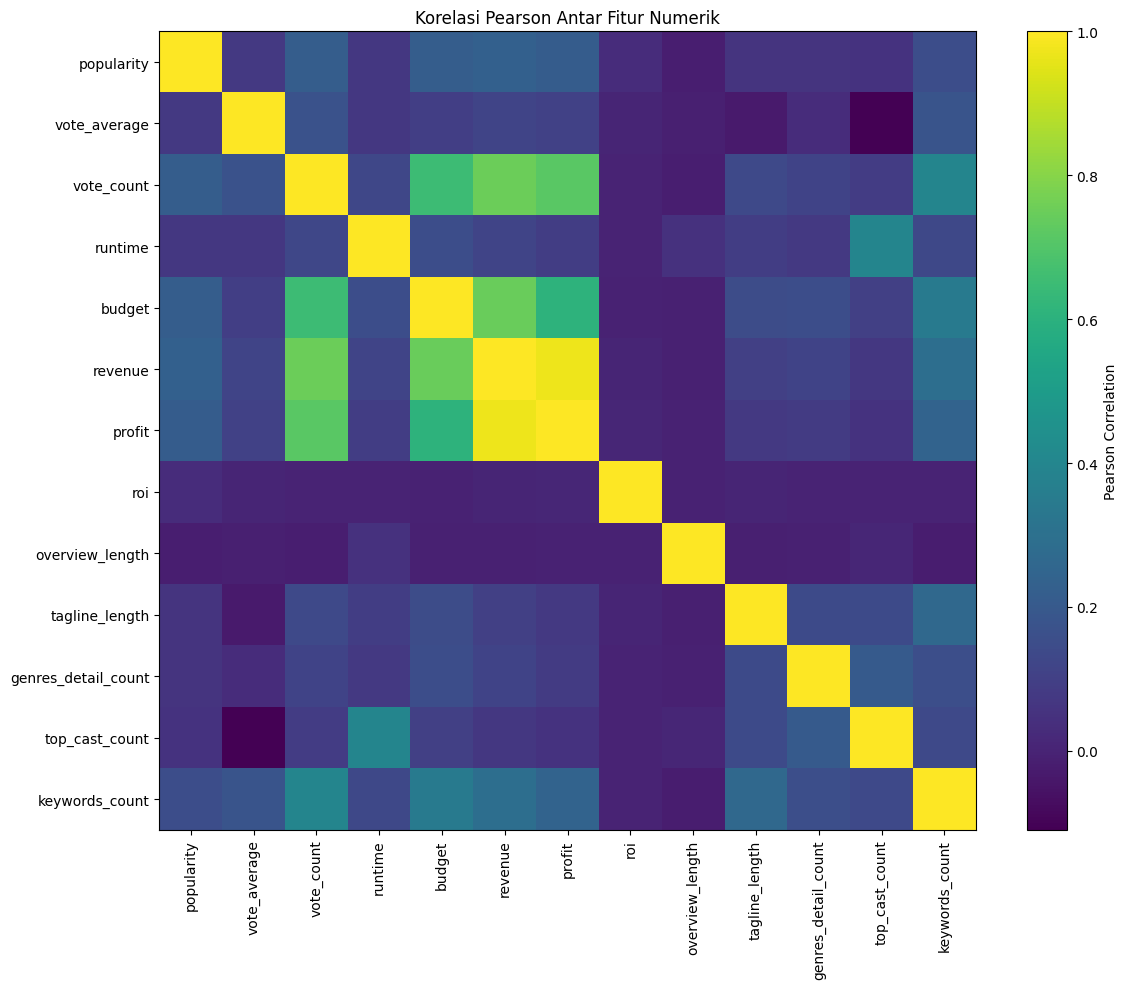

In [60]:
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix.astype(float), aspect="auto")
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Korelasi Pearson Antar Fitur Numerik")
plt.tight_layout()
save_fig("correlation_heatmap.png")
plt.show()

## 61. Scatter Plot Popularity vs Vote Count

Cell ini melihat hubungan antara popularity dan vote count.

Kedua kolom menggunakan transformasi log agar outlier besar tidak terlalu mendominasi.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\scatter_vote_count_popularity.png


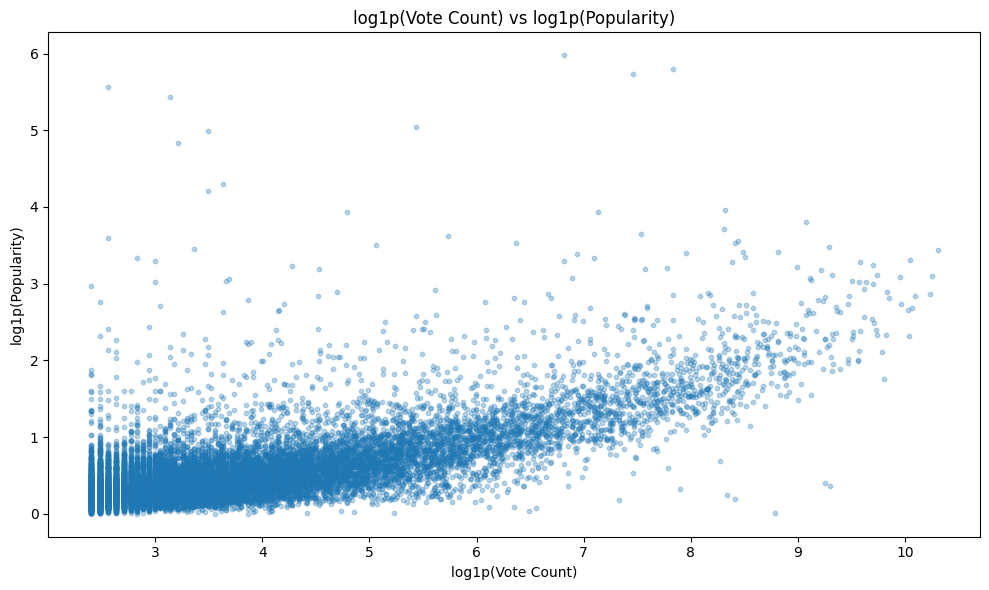

In [61]:
scatter_pop_vote_pd = (
    df
    .select(
        F.log1p("popularity").alias("log_popularity"),
        F.log1p("vote_count").alias("log_vote_count"),
        "vote_average"
    )
    .dropna()
    .sample(False, 0.2, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.scatter(scatter_pop_vote_pd["log_vote_count"], scatter_pop_vote_pd["log_popularity"], alpha=0.3, s=10)
plt.title("log1p(Vote Count) vs log1p(Popularity)")
plt.xlabel("log1p(Vote Count)")
plt.ylabel("log1p(Popularity)")
plt.tight_layout()
save_fig("scatter_vote_count_popularity.png")
plt.show()

## 62. Scatter Plot Budget vs Revenue

Cell ini melihat hubungan antara budget dan revenue pada subset finansial valid.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\scatter_budget_revenue.png


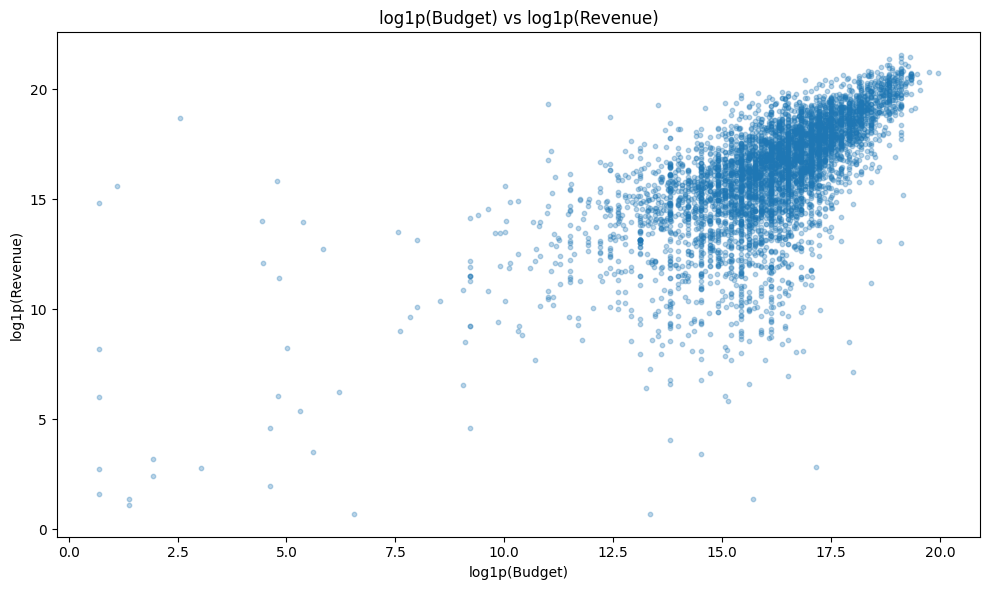

In [62]:
budget_revenue_pd = (
    financial_df
    .select("log_budget", "log_revenue", "vote_average")
    .dropna()
    .sample(False, 0.5, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.scatter(budget_revenue_pd["log_budget"], budget_revenue_pd["log_revenue"], alpha=0.3, s=10)
plt.title("log1p(Budget) vs log1p(Revenue)")
plt.xlabel("log1p(Budget)")
plt.ylabel("log1p(Revenue)")
plt.tight_layout()
save_fig("scatter_budget_revenue.png")
plt.show()

# Bagian J — Top Movies dan Insight Rekomendasi

Bagian ini menampilkan film-film teratas berdasarkan beberapa sudut pandang.

## 63. Top Movies Berdasarkan Popularity

Cell ini menampilkan film paling populer berdasarkan skor `popularity`.

In [63]:
top_popularity_pd = (
    df
    .select("id", "title", "release_year", "genres_detail", "director", "top_cast", "popularity", "vote_average", "vote_count")
    .orderBy(F.desc("popularity"))
    .limit(20)
    .toPandas()
)

top_popularity_pd

,id,title,release_year,genres_detail,director,top_cast,popularity,vote_average,vote_count
0,1339713,Obsession,2026,Horror | Thriller,Curry Barker,Michael Johnston | Inde Navarrette | Cooper Tomlinson | Megan Lawless | Andy Richter | Haley Fitzgerald | Darin Toon...,881.8242,7.900,679
1,1057265,Peddi,2026,Action | Drama,Buchi Babu Sana,Ram Charan | Janhvi Kapoor | Shiva Rajkumar | Jagapati Babu | Divyendu Sharma | Rajatabha Dutta | Dayanand Reddy | U...,879.8593,6.466,29
2,1308553,Hai Jawani Toh Ishq Hona Hai,2026,Romance | Comedy,David Dhawan,Varun Dhawan | Mrunal Thakur | Pooja Hegde | Maniesh Paul | Chunky Panday | Jimmy Shergill | Mouni Roy | Rakesh Bedi...,542.0340,5.500,13
3,931285,Mortal Kombat II,2026,Action | Fantasy | Adventure,Simon McQuoid,Karl Urban | Adeline Rudolph | Jessica McNamee | Josh Lawson | Martyn Ford | Ludi Lin | Mehcad Brooks | Tati Gabriel...,393.3846,7.938,915
4,936075,Michael,2026,Music | Drama,Antoine Fuqua,Jaafar Jackson | Colman Domingo | Nia Long | Juliano Krue Valdi | Miles Teller | KeiLyn Durrel Jones | Kendrick Samp...,361.7812,8.464,1745
5,1228710,The Mandalorian and Grogu,2026,Action | Adventure | Science Fiction,Jon Favreau,Pedro Pascal | Jeremy Allen White | Sigourney Weaver | Brendan Wayne | Lateef Crowder | Steve Blum | Jonny Coyne | M...,347.3910,6.800,443
6,1226863,The Super Mario Galaxy Movie,2026,Family | Comedy | Adventure | Fantasy | Animation,Aaron Horvath | Michael Jelenic,Chris Pratt | Anya Taylor-Joy | Charlie Day | Jack Black | Donald Glover | Benny Safdie | Brie Larson | Keegan-Micha...,328.3150,8.166,2517
7,454639,Masters of the Universe,2026,Action | Fantasy | Science Fiction,Travis Knight,Nicholas Galitzine | Camila Mendes | Idris Elba | Jared Leto | Alison Brie | Jóhannes Haukur Jóhannesson | Jon Xue Z...,321.5434,7.400,166
8,1304313,Lee Cronin's The Mummy,2026,Horror | Mystery,Lee Cronin,Jack Reynor | Laia Costa | May Calamawy | Natalie Grace | Shylo Molina | Billie Roy | Veronica Falcón | Hayat Kamill...,306.9250,8.100,1742
9,1367220,Karuppu,2026,Action | Fantasy,RJ Balaji,Suriya | Trisha Krishnan | RJ Balaji | Indrans | Anagha Maya Ravi | Swasika | Sshivada | Natarajan Subramaniam | Sup...,260.4269,7.600,12


## 64. Top Movies Berdasarkan Rating dengan Vote Minimum

Cell ini menampilkan film dengan rating tertinggi, tetapi hanya untuk film yang memiliki jumlah vote cukup.

Filter ini penting agar film dengan rating tinggi tetapi vote sangat sedikit tidak mendominasi.

In [64]:
MIN_VOTE_COUNT_FOR_TOP_RATING = 1000

top_rating_pd = (
    df
    .filter(F.col("vote_count") >= MIN_VOTE_COUNT_FOR_TOP_RATING)
    .select("id", "title", "release_year", "genres_detail", "director", "top_cast", "vote_average", "vote_count", "popularity")
    .orderBy(F.desc("vote_average"), F.desc("vote_count"))
    .limit(20)
    .toPandas()
)

top_rating_pd

,id,title,release_year,genres_detail,director,top_cast,vote_average,vote_count,popularity
0,1007757,Swapped,2026,Adventure | Animation | Family | Fantasy,Nathan Greno,Michael B. Jordan | Juno Temple | Tracy Morgan | Cedric the Entertainer | Justina Machado | Nate Torrence | Camden B...,8.966,1647,193.7401
1,278,The Shawshank Redemption,1994,Drama | Crime,Frank Darabont,Tim Robbins | Morgan Freeman | Bob Gunton | William Sadler | Clancy Brown | Gil Bellows | James Whitmore | Mark Rols...,8.722,30528,91.8467
2,687163,Project Hail Mary,2026,Science Fiction | Adventure,Phil Lord | Christopher Miller,Ryan Gosling | Sandra Hüller | James Ortiz | Lionel Boyce | Milana Vayntrub | Ken Leung | Priya Kansara | Mia Soteri...,8.671,4888,198.4691
3,424,Schindler's List,1993,Drama | History | War,Steven Spielberg,Liam Neeson | Ben Kingsley | Ralph Fiennes | Caroline Goodall | Jonathan Sagall | Embeth Davidtz | Małgorzata Gebel ...,8.569,17501,27.6335
4,129,Spirited Away,2001,Animation | Family | Fantasy,Hayao Miyazaki,Rumi Hiiragi | Miyu Irino | Mari Natsuki | Takashi Naito | Yasuko Sawaguchi | Tatsuya Gashûin | Ryunosuke Kamiki | Y...,8.535,18389,31.4985
5,155,The Dark Knight,2008,Action | Crime | Thriller,Christopher Nolan,Christian Bale | Heath Ledger | Aaron Eckhart | Michael Caine | Maggie Gyllenhaal | Gary Oldman | Morgan Freeman | M...,8.531,35874,38.8635
6,19404,Dilwale Dulhania Le Jayenge,1995,Comedy | Drama | Romance,Aditya Chopra,Kajol | Shah Rukh Khan | Amrish Puri | Farida Jalal | Anupam Kher | Pooja Ruparel | Parmeet Sethi | Satish Shah | Ma...,8.513,4593,16.2564
7,497,The Green Mile,1999,Fantasy | Drama | Crime,Frank Darabont,Tom Hanks | David Morse | Bonnie Hunt | Michael Clarke Duncan | James Cromwell | Michael Jeter | Graham Greene | Dou...,8.507,19311,28.7127
8,122,The Lord of the Rings: The Return of the King,2003,Adventure | Fantasy | Action,Peter Jackson,Elijah Wood | Ian McKellen | Viggo Mortensen | Sean Astin | Andy Serkis | Dominic Monaghan | Billy Boyd | John Noble...,8.499,26624,46.0910
9,496243,Parasite,2019,Comedy | Thriller | Drama,Bong Joon Ho,Song Kang-ho | Lee Sun-kyun | Cho Yeo-jeong | Choi Woo-shik | Park So-dam | Lee Jung-eun | Jang Hye-jin | Park Myung...,8.494,20704,34.9593


## 65. Top Movies Berdasarkan Vote Count

Cell ini menampilkan film yang paling banyak mendapatkan vote.

In [65]:
top_vote_count_pd = (
    df
    .select("id", "title", "release_year", "genres_detail", "director", "top_cast", "vote_average", "vote_count", "popularity")
    .orderBy(F.desc("vote_count"))
    .limit(20)
    .toPandas()
)

top_vote_count_pd

,id,title,release_year,genres_detail,director,top_cast,vote_average,vote_count,popularity
0,157336,Interstellar,2014,Adventure | Drama | Science Fiction,Christopher Nolan,Matthew McConaughey | Anne Hathaway | Michael Caine | Jessica Chastain | Casey Affleck | Wes Bentley | Topher Grace ...,8.478,39973,67.4273
1,27205,Inception,2010,Action | Science Fiction | Adventure,Christopher Nolan,Leonardo DiCaprio | Joseph Gordon-Levitt | Ken Watanabe | Tom Hardy | Elliot Page | Dileep Rao | Cillian Murphy | To...,8.372,39339,33.3385
2,24428,The Avengers,2012,Science Fiction | Action | Adventure,Joss Whedon,Robert Downey Jr. | Chris Evans | Mark Ruffalo | Chris Hemsworth | Scarlett Johansson | Jeremy Renner | Tom Hiddlest...,8.041,38277,52.4408
3,155,The Dark Knight,2008,Action | Crime | Thriller,Christopher Nolan,Christian Bale | Heath Ledger | Aaron Eckhart | Michael Caine | Maggie Gyllenhaal | Gary Oldman | Morgan Freeman | M...,8.531,35874,38.8635
4,19995,Avatar,2009,Science Fiction | Action | Adventure,James Cameron,Sam Worthington | Zoe Saldaña | Sigourney Weaver | Stephen Lang | Michelle Rodriguez | Giovanni Ribisi | Joel David ...,7.606,34041,44.4028
5,293660,Deadpool,2016,Action | Adventure | Comedy,Tim Miller,Ryan Reynolds | Morena Baccarin | Ed Skrein | T.J. Miller | Gina Carano | Leslie Uggams | Brianna Hildebrand | Stefa...,7.624,32774,16.3145
6,550,Fight Club,1999,Drama | Thriller,David Fincher,Edward Norton | Brad Pitt | Helena Bonham Carter | Meat Loaf | Jared Leto | Zach Grenier | Holt McCallany | Eion Bai...,8.438,32124,27.4563
7,299536,Avengers: Infinity War,2018,Adventure | Action | Science Fiction,Joe Russo | Anthony Russo,Robert Downey Jr. | Chris Evans | Chris Hemsworth | Josh Brolin | Mark Ruffalo | Scarlett Johansson | Don Cheadle | ...,8.237,32078,48.0912
8,278,The Shawshank Redemption,1994,Drama | Crime,Frank Darabont,Tim Robbins | Morgan Freeman | Bob Gunton | William Sadler | Clancy Brown | Gil Bellows | James Whitmore | Mark Rols...,8.722,30528,91.8467
9,680,Pulp Fiction,1994,Thriller | Crime | Comedy,Quentin Tarantino,John Travolta | Samuel L. Jackson | Uma Thurman | Bruce Willis | Ving Rhames | Harvey Keitel | Eric Stoltz | Tim Rot...,8.483,30263,32.6812


# Bagian K — Kesiapan Data untuk Model Rekomendasi

Bagian ini mengecek kesiapan kolom yang akan digunakan untuk membuat fitur rekomendasi film.

## 66. Mengecek Kelengkapan Fitur Rekomendasi

Cell ini mengecek kolom yang kemungkinan besar akan dipakai untuk model:

- `title`
- `overview`
- `genres_detail`
- `director`
- `writers`
- `top_cast`
- `keywords`

Jika banyak missing pada suatu kolom, kolom tersebut masih bisa dipakai, tetapi perlu diisi string kosong saat membuat `movie_document`.

In [66]:
recommendation_feature_cols = [
    "title", "overview", "genres_detail", "director",
    "writers", "top_cast", "keywords",
    "original_language", "release_year", "vote_average", "vote_count", "popularity"
]

recommendation_feature_cols = [c for c in recommendation_feature_cols if c in df.columns]

recommendation_missing_pd = missing_pd[missing_pd["column"].isin(recommendation_feature_cols)].copy()
recommendation_missing_pd

,column,missing_count,missing_pct
4,keywords,25427,31.50
6,writers,7073,8.76
10,top_cast,1520,1.88
11,overview,548,0.68
13,genres_detail,379,0.47
16,director,355,0.44
20,original_language,0,0.00
24,vote_count,0,0.00
25,vote_average,0,0.00
26,popularity,0,0.00


## 67. Membuat Movie Document Contoh

Cell ini membuat contoh `movie_document`, yaitu gabungan teks dari beberapa metadata film.

Movie document ini nantinya bisa dipakai untuk:
- TF-IDF.
- CountVectorizer.
- Embedding.
- Qdrant vector database.
- RAG dengan n8n.

In [67]:
df_doc_preview = (
    df
    .withColumn(
        "movie_document",
        F.concat_ws(
            " ",
            F.concat(F.lit("Title: "), F.coalesce(F.col("title"), F.lit(""))),
            F.concat(F.lit("Overview: "), F.coalesce(F.col("overview"), F.lit(""))),
            F.concat(F.lit("Genres: "), F.coalesce(F.col("genres_detail"), F.coalesce(F.col("genres"), F.lit("")))),
            F.concat(F.lit("Director: "), F.coalesce(F.col("director"), F.lit(""))),
            F.concat(F.lit("Writers: "), F.coalesce(F.col("writers"), F.lit(""))),
            F.concat(F.lit("Cast: "), F.coalesce(F.col("top_cast"), F.lit(""))),
            F.concat(F.lit("Keywords: "), F.coalesce(F.col("keywords"), F.lit(""))),
            F.concat(F.lit("Language: "), F.coalesce(F.col("original_language"), F.lit(""))),
            F.concat(F.lit("Year: "), F.coalesce(F.col("release_year").cast("string"), F.lit(""))),
        )
    )
    .select("id", "title", "movie_document")
)

df_doc_preview.show(5, truncate=200)

+------+------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|    id|                   title|                                                                                                                                                                                          movie_document|
+------+------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|  8738|     The Final Countdown|Title: The Final Countdown Overview: During routine manoeuvres near Hawaii in 1980, the aircraft-carrier USS Nimitz is caught in a strange vortex-like storm, throwing the ship back in time to 1941—...|
|292824|Secrets of a French Maid|Title: Secrets of a French 

## 68. Menghitung Panjang Movie Document

Cell ini menghitung panjang `movie_document`.

Tujuannya:
- Mengetahui apakah dokumen terlalu pendek.
- Mengetahui apakah ada dokumen terlalu panjang.
- Menjadi dasar untuk preprocessing teks.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\distribution_movie_document_length.png


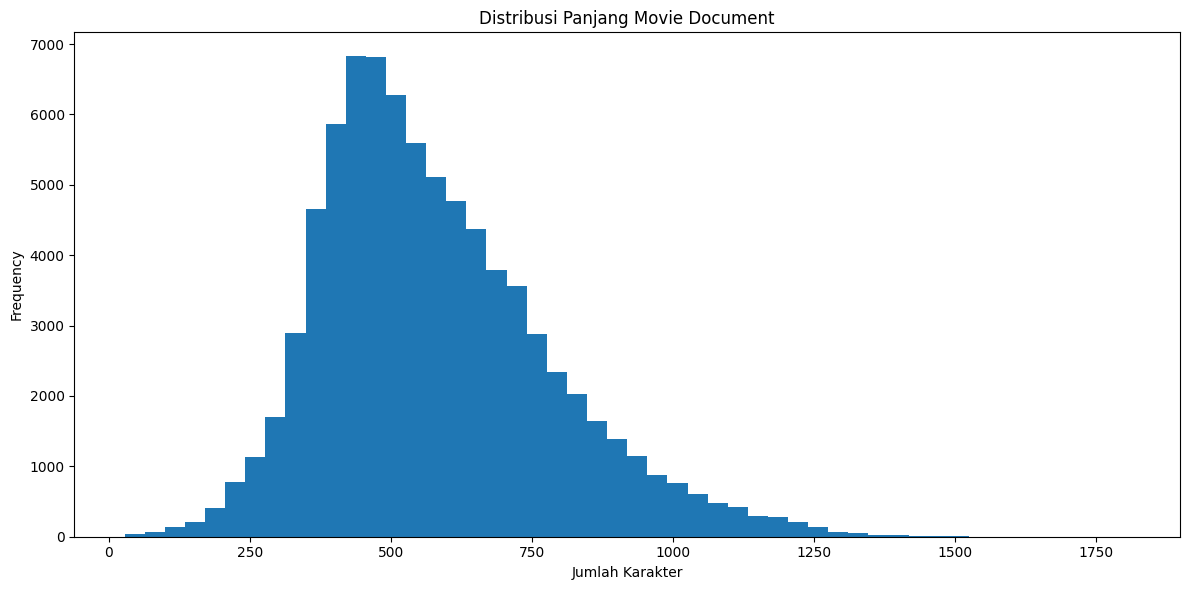

+-------+--------------------+---------------------+
|id     |title               |movie_document_length|
+-------+--------------------+---------------------+
|493767 |Cat                 |28                   |
|869732 |Man                 |30                   |
|884016 |X                   |31                   |
|365820 |NM                  |33                   |
|611974 |Retando A La Muerte |33                   |
|358626 |Il mio eroe Paperino|34                   |
|519722 |Disney’s Scary Tales|34                   |
|1634858|Cuerno Azulado      |34                   |
|1472938|Formula vody        |35                   |
|785899 |2097                |40                   |
+-------+--------------------+---------------------+
only showing top 10 rows


In [68]:
df_doc = (
    df
    .withColumn(
        "movie_document",
        F.concat_ws(
            " ",
            F.coalesce(F.col("title"), F.lit("")),
            F.coalesce(F.col("overview"), F.lit("")),
            F.coalesce(F.col("genres_detail"), F.coalesce(F.col("genres"), F.lit(""))),
            F.coalesce(F.col("director"), F.lit("")),
            F.coalesce(F.col("writers"), F.lit("")),
            F.coalesce(F.col("top_cast"), F.lit("")),
            F.coalesce(F.col("keywords"), F.lit("")),
            F.coalesce(F.col("original_language"), F.lit("")),
            F.coalesce(F.col("release_year").cast("string"), F.lit(""))
        )
    )
    .withColumn("movie_document_length", F.length("movie_document"))
    .cache()
)

doc_length_pd = df_doc.select("movie_document_length").toPandas()

plot_hist_from_pandas(
    doc_length_pd,
    "movie_document_length",
    "Distribusi Panjang Movie Document",
    bins=50,
    xlabel="Jumlah Karakter",
    filename="distribution_movie_document_length.png"
)

df_doc.select("id", "title", "movie_document_length").orderBy(F.asc("movie_document_length")).show(10, truncate=False)

## 69. Membuat Skor Kelengkapan Metadata

Cell ini membuat `metadata_completeness_score`, yaitu skor sederhana untuk menilai kelengkapan informasi film.

Skor dihitung dari fitur:
- Ada overview.
- Ada genre.
- Ada director.
- Ada top cast.
- Ada keywords.
- Ada poster.
- Ada runtime.
- Ada vote_count.
- Ada release_date.

Skor ini bukan model, tetapi membantu memilih data yang lebih berkualitas untuk training atau rekomendasi.

Saved figure: d:\Semester 6\BigData\movie-recommendation-bigdata\reports\figures\metadata_completeness_score.png


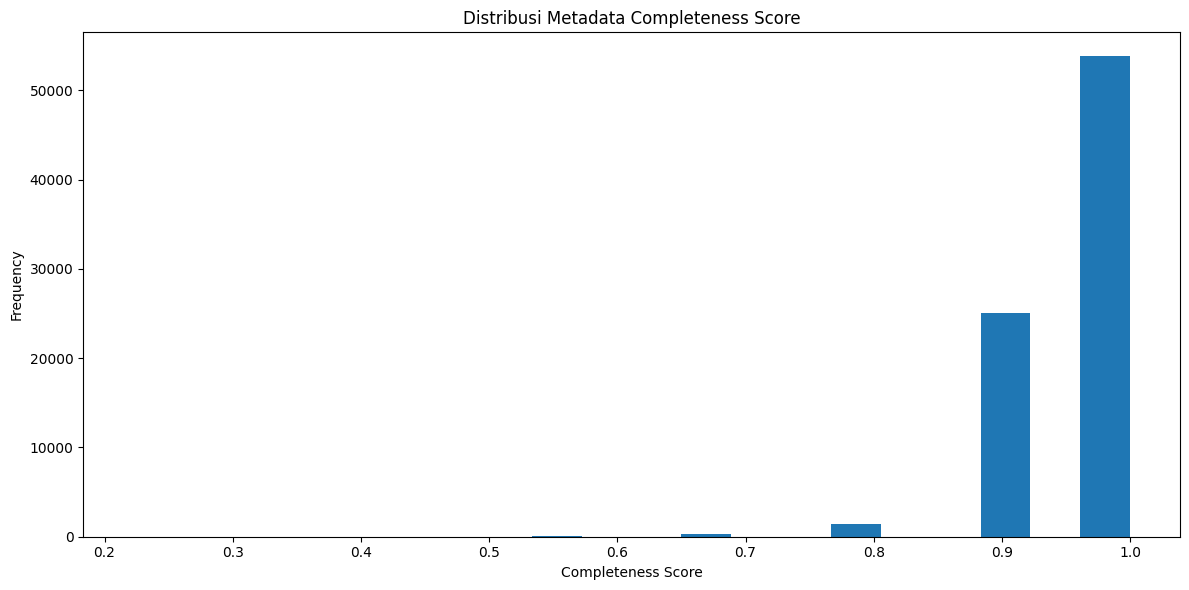

+-------+------------------------------------------------------------+---------------------------+
|id     |title                                                       |metadata_completeness_score|
+-------+------------------------------------------------------------+---------------------------+
|338289 |Twisted Sister: We're Not Gonna Take It                     |0.2222222222222222         |
|519722 |Disney’s Scary Tales                                        |0.3333333333333333         |
|611974 |Retando A La Muerte                                         |0.3333333333333333         |
|358626 |Il mio eroe Paperino                                        |0.3333333333333333         |
|884016 |X                                                           |0.3333333333333333         |
|1221060|Abhi To Main Jawan Hoon                                     |0.4444444444444444         |
|707243 |El Ruiseñor de América - Julio Jaramillo                    |0.4444444444444444         |
|275781 |F

In [69]:
df_quality = (
    df
    .withColumn("has_genre", F.when(F.length(F.trim(F.coalesce(F.col("genres_detail"), F.coalesce(F.col("genres"), F.lit(""))))) > 0, 1).otherwise(0))
    .withColumn("has_director", F.when(F.length(F.trim(F.coalesce(F.col("director"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_top_cast", F.when(F.length(F.trim(F.coalesce(F.col("top_cast"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_keywords", F.when(F.length(F.trim(F.coalesce(F.col("keywords"), F.lit("")))) > 0, 1).otherwise(0))
    .withColumn("has_runtime_valid", F.when(F.col("runtime") > 0, 1).otherwise(0))
    .withColumn("has_vote_count_valid", F.when(F.col("vote_count") > 0, 1).otherwise(0))
    .withColumn("has_release_date", F.when(F.col("release_date_parsed").isNotNull(), 1).otherwise(0))
    .withColumn(
        "metadata_completeness_score",
        (
            F.col("has_overview") +
            F.col("has_genre") +
            F.col("has_director") +
            F.col("has_top_cast") +
            F.col("has_keywords") +
            F.col("has_poster") +
            F.col("has_runtime_valid") +
            F.col("has_vote_count_valid") +
            F.col("has_release_date")
        ) / F.lit(9.0)
    )
    .cache()
)

quality_score_pd = df_quality.select("metadata_completeness_score").toPandas()

plot_hist_from_pandas(
    quality_score_pd,
    "metadata_completeness_score",
    "Distribusi Metadata Completeness Score",
    bins=20,
    xlabel="Completeness Score",
    filename="metadata_completeness_score.png"
)

df_quality.select("id", "title", "metadata_completeness_score").orderBy(F.asc("metadata_completeness_score")).show(20, truncate=False)

## 70. Ringkasan Kesiapan Data untuk Preprocessing

Cell ini membuat ringkasan jumlah film berdasarkan kualitas metadata.

In [70]:
quality_summary_pd = df_quality.agg(
    F.count("*").alias("total_movies"),
    F.sum(F.when(F.col("metadata_completeness_score") >= 0.8, 1).otherwise(0)).alias("score_gte_0_8"),
    F.sum(F.when(F.col("metadata_completeness_score") >= 0.6, 1).otherwise(0)).alias("score_gte_0_6"),
    F.avg("metadata_completeness_score").alias("avg_metadata_completeness_score"),
).toPandas()

quality_summary_pd

,total_movies,score_gte_0_8,score_gte_0_6,avg_metadata_completeness_score
0,80713,78879,80612,0.959643


# Bagian L — Menyimpan Output EDA

Bagian ini menyimpan beberapa tabel hasil EDA ke folder `data/interim/eda/`.

File-file ini bisa dipakai untuk laporan, presentasi, atau tahap preprocessing berikutnya.

## 71. Menyimpan Tabel Ringkasan EDA

Cell ini menyimpan beberapa tabel ringkasan sebagai CSV.

Output yang dibuat:
- `missing_values_summary.csv`
- `yearly_movie_count.csv`
- `decade_movie_count.csv`
- `top_genres.csv`
- `genre_stats.csv`
- `top_directors.csv`
- `top_cast.csv`
- `top_keywords.csv`
- `language_stats.csv`
- `financial_availability.csv`
- `quality_summary.csv`

In [71]:
missing_pd.to_csv(OUTPUT_DIR / "missing_values_summary.csv", index=False)
yearly_count_pd.to_csv(OUTPUT_DIR / "yearly_movie_count.csv", index=False)
decade_count_pd.to_csv(OUTPUT_DIR / "decade_movie_count.csv", index=False)
top_genres_pd.to_csv(OUTPUT_DIR / "top_genres.csv", index=False)
genre_stats_pd.to_csv(OUTPUT_DIR / "genre_stats.csv", index=False)
top_directors_pd.to_csv(OUTPUT_DIR / "top_directors.csv", index=False)
top_cast_pd.to_csv(OUTPUT_DIR / "top_cast.csv", index=False)
top_keywords_pd.to_csv(OUTPUT_DIR / "top_keywords.csv", index=False)
language_stats_pd.to_csv(OUTPUT_DIR / "language_stats.csv", index=False)
financial_availability_pd.to_csv(OUTPUT_DIR / "financial_availability.csv", index=False)
quality_summary_pd.to_csv(OUTPUT_DIR / "quality_summary.csv", index=False)
data_dictionary_pd.to_csv(OUTPUT_DIR / "data_dictionary.csv", index=False)

print("EDA summary files saved to:", OUTPUT_DIR)

EDA summary files saved to: d:\Semester 6\BigData\movie-recommendation-bigdata\data\interim\eda


## 72. Menyimpan Dataset dengan Fitur EDA Tambahan

Cell ini menyimpan dataset yang sudah ditambahkan beberapa fitur turunan, seperti:
- `release_year`
- `release_month`
- `release_decade`
- `profit`
- `roi`
- `runtime_category`
- `metadata_completeness_score`

Output disimpan dalam format Parquet karena lebih cocok untuk workflow Big Data dibanding CSV.

In [74]:
import pandas as pd

EDA_FEATURE_OUTPUT_CSV = OUTPUT_DIR / "tmdb_movies_with_eda_features.csv"

pdf_quality = df_quality.toPandas()
pdf_quality.to_csv(EDA_FEATURE_OUTPUT_CSV, index=False)

print("Saved:", EDA_FEATURE_OUTPUT_CSV)
print("Rows:", len(pdf_quality))
print("Columns:", len(pdf_quality.columns))

Saved: d:\Semester 6\BigData\movie-recommendation-bigdata\data\interim\eda\tmdb_movies_with_eda_features.csv
Rows: 80713
Columns: 71


# Bagian M — Kesimpulan Awal EDA

Bagian ini membantu menyusun insight otomatis dari hasil EDA.

Kamu tetap perlu membaca hasil tabel/grafik di atas, tetapi cell ini memberi ringkasan awal yang bisa dijadikan bahan laporan.

## 73. Membuat Ringkasan Insight Otomatis

Cell ini membuat teks ringkasan dari beberapa hasil EDA.

Teks ini bisa dipakai sebagai draft awal untuk bagian hasil dan pembahasan.

In [75]:
total_movies = int(profile_pd.loc[0, "total_rows"])
unique_movies = int(profile_pd.loc[0, "unique_movie_id"])
min_year = profile_pd.loc[0, "min_release_year"]
max_year = profile_pd.loc[0, "max_release_year"]

top_genre = top_genres_pd.iloc[0]["genre"] if len(top_genres_pd) else "-"
top_language = language_pd.iloc[0]["original_language"] if len(language_pd) else "-"
avg_quality_score = float(quality_summary_pd.loc[0, "avg_metadata_completeness_score"])

financial_valid = int(financial_availability_pd.loc[0, "movies_with_budget_and_revenue"])
financial_valid_pct = float(financial_availability_pd.loc[0, "budget_revenue_pct"])

insight_text = f'''
Ringkasan awal EDA:

1. Dataset berisi {total_movies:,} baris film dengan {unique_movies:,} ID film unik.
2. Rentang tahun rilis film berada pada sekitar tahun {min_year} sampai {max_year}.
3. Genre yang paling banyak muncul adalah "{top_genre}".
4. Bahasa asli yang paling dominan adalah "{top_language}".
5. Jumlah film yang memiliki budget dan revenue valid adalah {financial_valid:,} film atau sekitar {financial_valid_pct:.2f}% dari dataset.
6. Rata-rata metadata completeness score adalah {avg_quality_score:.3f}.
7. Untuk model rekomendasi, fitur yang paling potensial digunakan adalah title, overview, genres_detail, director, writers, top_cast, keywords, original_language, release_year, vote_average, vote_count, dan popularity.
8. Kolom budget dan revenue sebaiknya tidak dijadikan fitur utama untuk semua film karena kelengkapannya biasanya terbatas.
9. Movie document dapat dibuat dari gabungan overview, genre, director, cast, writers, dan keywords.
10. Data perlu dibersihkan lagi sebelum training, terutama pada missing value teks, nilai budget/revenue nol, dan film dengan metadata sangat tidak lengkap.
'''

print(insight_text)

with open(OUTPUT_DIR / "eda_initial_insights.txt", "w", encoding="utf-8") as f:
    f.write(insight_text)

print("Saved:", OUTPUT_DIR / "eda_initial_insights.txt")


Ringkasan awal EDA:

1. Dataset berisi 80,713 baris film dengan 80,713 ID film unik.
2. Rentang tahun rilis film berada pada sekitar tahun 1980 sampai 2026.
3. Genre yang paling banyak muncul adalah "Drama".
4. Bahasa asli yang paling dominan adalah "en".
5. Jumlah film yang memiliki budget dan revenue valid adalah 10,328 film atau sekitar 12.80% dari dataset.
6. Rata-rata metadata completeness score adalah 0.960.
7. Untuk model rekomendasi, fitur yang paling potensial digunakan adalah title, overview, genres_detail, director, writers, top_cast, keywords, original_language, release_year, vote_average, vote_count, dan popularity.
8. Kolom budget dan revenue sebaiknya tidak dijadikan fitur utama untuk semua film karena kelengkapannya biasanya terbatas.
9. Movie document dapat dibuat dari gabungan overview, genre, director, cast, writers, dan keywords.
10. Data perlu dibersihkan lagi sebelum training, terutama pada missing value teks, nilai budget/revenue nol, dan film dengan metadata sa

## 74. Rekomendasi Preprocessing Setelah EDA

Berdasarkan struktur dataset TMDB, preprocessing yang disarankan:

1. **Deduplikasi**
   - Gunakan `id` sebagai primary key.
   - Pastikan tidak ada film ganda.

2. **Handling Missing Value**
   - Kolom teks seperti `overview`, `director`, `top_cast`, dan `keywords` bisa diisi string kosong.
   - Kolom numerik seperti `runtime`, `vote_average`, dan `vote_count` perlu dicek apakah missing atau bernilai tidak wajar.
   - `budget = 0` dan `revenue = 0` sebaiknya dianggap sebagai tidak tersedia untuk analisis finansial.

3. **Feature Engineering**
   - Buat `release_year`, `release_decade`, `runtime_category`.
   - Buat `movie_document` dari gabungan metadata film.
   - Buat `metadata_completeness_score` untuk menilai kualitas data.

4. **Feature untuk Model Rekomendasi**
   - Untuk TF-IDF: gunakan `movie_document`.
   - Untuk metadata filter: gunakan `genres_detail`, `director`, `top_cast`, `release_year`, `vote_average`, `vote_count`.
   - Untuk RAG/Qdrant: gunakan `movie_document` sebagai teks embedding.

5. **Kolom yang Berpotensi Dihapus**
   - `poster_path`, `backdrop_path`, `homepage` jika tidak dipakai di frontend.
   - `source_*` jika tidak diperlukan pada model.
   - `budget` dan `revenue` bisa tetap disimpan di MongoDB, tetapi tidak wajib dipakai sebagai fitur utama.

## 75. Menutup SparkSession

Jalankan cell ini jika seluruh analisis sudah selesai.

Jika kamu masih ingin menjalankan cell lain, jangan tutup SparkSession dulu.

In [ ]:
# Jalankan hanya jika EDA sudah selesai
# spark.stop()